In [1]:
# ============================================================
# CELL 1 — VERIFY CHB03 DATA
# ============================================================

from pathlib import Path

CHB03_DIR = Path(
    r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\data\multi_patient\chb03"
)

edf_files = sorted(CHB03_DIR.glob("*.edf"))
seizure_files = sorted(CHB03_DIR.glob("*.edf.seizures"))

print("========================================")
print("CHB03 DATA VERIFICATION")
print("========================================")

print(f"CHB03 folder exists: {CHB03_DIR.exists()}")
print(f"EDF files found: {len(edf_files)}")
print(f"Seizure annotation files found: {len(seizure_files)}")

print("\nFirst 5 EDF files:")
for f in edf_files[:5]:
    print(" ", f.name)

print("\nSeizure annotation files:")
for f in seizure_files:
    print(" ", f.name)

CHB03 DATA VERIFICATION
CHB03 folder exists: True
EDF files found: 38
Seizure annotation files found: 7

First 5 EDF files:
  chb03_01.edf
  chb03_02.edf
  chb03_03.edf
  chb03_04.edf
  chb03_05.edf

Seizure annotation files:
  chb03_01.edf.seizures
  chb03_02.edf.seizures
  chb03_03.edf.seizures
  chb03_04.edf.seizures
  chb03_34.edf.seizures
  chb03_35.edf.seizures
  chb03_36.edf.seizures


In [2]:
# ============================================================
# CELL 2 — READ CHB03 SUMMARY
# ============================================================

summary_path = CHB03_DIR / "chb03-summary.txt"

with open(summary_path, "r", encoding="utf-8") as f:
    summary_text = f.read()

print(summary_text)

Data Sampling Rate: 256 Hz
*************************

Channels in EDF Files:
**********************
Channel 1: FP1-F7
Channel 2: F7-T7
Channel 3: T7-P7
Channel 4: P7-O1
Channel 5: FP1-F3
Channel 6: F3-C3
Channel 7: C3-P3
Channel 8: P3-O1
Channel 9: FP2-F4
Channel 10: F4-C4
Channel 11: C4-P4
Channel 12: P4-O2
Channel 13: FP2-F8
Channel 14: F8-T8
Channel 15: T8-P8
Channel 16: P8-O2
Channel 17: FZ-CZ
Channel 18: CZ-PZ
Channel 19: P7-T7
Channel 20: T7-FT9
Channel 21: FT9-FT10
Channel 22: FT10-T8
Channel 23: T8-P8

File Name: chb03_01.edf
File Start Time: 13:23:36
File End Time: 14:23:36
Number of Seizures in File: 1
Seizure Start Time: 362 seconds
Seizure End Time: 414 seconds

File Name: chb03_02.edf
File Start Time: 14:23:39
File End Time: 15:23:39
Number of Seizures in File: 1
Seizure Start Time: 731 seconds
Seizure End Time: 796 seconds

File Name: chb03_03.edf
File Start Time: 15:23:47
File End Time: 16:23:47
Number of Seizures in File: 1
Seizure Start Time: 432 seconds
Seizure End Ti

In [3]:
# ============================================================
# CELL 3 — VERIFY CHB03 EDF METADATA
# ============================================================

import mne

test_file = CHB03_DIR / "chb03_01.edf"

raw = mne.io.read_raw_edf(
    test_file,
    preload=False,
    verbose=False
)

print("========================================")
print("CHB03 EDF METADATA")
print("========================================")

print(f"File: {test_file.name}")
print(f"Channels: {len(raw.ch_names)}")
print(f"Sampling frequency: {raw.info['sfreq']} Hz")
print(f"Duration: {raw.times[-1]:.2f} seconds")

print("\nFirst 5 channels:")
for ch in raw.ch_names[:5]:
    print(" ", ch)

C:\Users\Prajapati_Shivam\AppData\Local\Temp\ipykernel_29684\3506670266.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


CHB03 EDF METADATA
File: chb03_01.edf
Channels: 23
Sampling frequency: 256.0 Hz
Duration: 3600.00 seconds

First 5 channels:
  FP1-F7
  F7-T7
  T7-P7
  P7-O1
  FP1-F3


In [4]:
# ============================================================
# CELL 4 — CHB03 SEIZURE ANNOTATION MAP
# ============================================================

seizure_annotations = {
    "chb03_01.edf": [(362, 414)],
    "chb03_02.edf": [(731, 796)],
    "chb03_03.edf": [(432, 501)],
    "chb03_04.edf": [(2162, 2214)],
    "chb03_34.edf": [(1982, 2029)],
    "chb03_35.edf": [(2592, 2656)],
    "chb03_36.edf": [(1725, 1778)],
}

print("========================================")
print("CHB03 SEIZURE ANNOTATIONS")
print("========================================")

print(f"Recordings with seizures: {len(seizure_annotations)}")

total_seizures = sum(
    len(events) for events in seizure_annotations.values()
)

print(f"Total annotated seizures: {total_seizures}")

print("\nSeizure recordings:")
for file_name, events in seizure_annotations.items():
    for start, end in events:
        print(f"{file_name}: {start} - {end} sec")

CHB03 SEIZURE ANNOTATIONS
Recordings with seizures: 7
Total annotated seizures: 7

Seizure recordings:
chb03_01.edf: 362 - 414 sec
chb03_02.edf: 731 - 796 sec
chb03_03.edf: 432 - 501 sec
chb03_04.edf: 2162 - 2214 sec
chb03_34.edf: 1982 - 2029 sec
chb03_35.edf: 2592 - 2656 sec
chb03_36.edf: 1725 - 1778 sec


In [5]:
# ============================================================
# CELL 5 — LOAD FROZEN CHB01 MODEL
# ============================================================

import joblib

MODEL_PATH = Path(
    r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\models\phase2_class_weighted_recording_wise.pkl"
)

model = joblib.load(MODEL_PATH)

print("========================================")
print("FROZEN CHB01 MODEL LOADED")
print("========================================")

print(f"Model path: {MODEL_PATH}")
print(f"Model type: {type(model).__name__}")
print(f"Number of estimators: {model.n_estimators}")
print(f"Classes: {model.classes_}")
print("Threshold: 0.05")
print("Model status: FROZEN — NO RETRAINING")

FROZEN CHB01 MODEL LOADED
Model path: C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\models\phase2_class_weighted_recording_wise.pkl
Model type: RandomForestClassifier
Number of estimators: 200
Classes: [0 1]
Threshold: 0.05
Model status: FROZEN — NO RETRAINING


In [6]:
# ============================================================
# CELL 6 — CHB03 FEATURE EXTRACTION SETTINGS
# ============================================================

import numpy as np
import pandas as pd
from scipy.signal import welch

WINDOW_SECONDS = 4
WINDOW_SAMPLES = 256 * WINDOW_SECONDS

BANDS = {
    "Delta": (0.5, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta": (13, 30),
    "Gamma": (30, 40),
}

FEATURE_COLUMNS = [
    "Mean",
    "Std",
    "Variance",
    "Delta",
    "Theta",
    "Alpha",
    "Beta",
    "Gamma",
]

print("========================================")
print("CHB03 FEATURE EXTRACTION SETTINGS")
print("========================================")

print(f"Sampling rate: 256 Hz")
print(f"Window duration: {WINDOW_SECONDS} seconds")
print(f"Samples per window: {WINDOW_SAMPLES}")

print("\nFrequency bands:")
for band, (low, high) in BANDS.items():
    print(f"  {band}: {low}-{high} Hz")

print("\nFeature columns:")
print(FEATURE_COLUMNS)

CHB03 FEATURE EXTRACTION SETTINGS
Sampling rate: 256 Hz
Window duration: 4 seconds
Samples per window: 1024

Frequency bands:
  Delta: 0.5-4 Hz
  Theta: 4-8 Hz
  Alpha: 8-13 Hz
  Beta: 13-30 Hz
  Gamma: 30-40 Hz

Feature columns:
['Mean', 'Std', 'Variance', 'Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']


In [7]:
# ============================================================
# CELL 7 — CHB03 FEATURE EXTRACTION FUNCTION
# ============================================================

def extract_features_from_window(window, sfreq=256):
    """
    Extract the same 8 features used by the frozen CHB01 model.
    Features are averaged across EEG channels.
    """

    features = {}

    # Statistical features
    features["Mean"] = np.mean(window)
    features["Std"] = np.std(window)
    features["Variance"] = np.var(window)

    # Power spectral density
    freqs, psd = welch(
        window,
        fs=sfreq,
        axis=-1,
        nperseg=min(256, window.shape[-1])
    )

    for band, (low, high) in BANDS.items():
        band_mask = (freqs >= low) & (freqs < high)

        if np.any(band_mask):
            band_power = np.mean(psd[..., band_mask], axis=-1)
            features[band] = np.mean(band_power)
        else:
            features[band] = 0.0

    return [
        features["Mean"],
        features["Std"],
        features["Variance"],
        features["Delta"],
        features["Theta"],
        features["Alpha"],
        features["Beta"],
        features["Gamma"],
    ]


print("========================================")
print("FEATURE EXTRACTION FUNCTION READY")
print("========================================")
print("Function: extract_features_from_window")
print("Output features: 8")
print("Channel aggregation: mean across channels")

FEATURE EXTRACTION FUNCTION READY
Function: extract_features_from_window
Output features: 8
Channel aggregation: mean across channels


In [8]:
# ============================================================
# CELL 8 — TEST FEATURE EXTRACTION ON ONE CHB03 WINDOW
# ============================================================

test_data = raw.get_data(
    start=0,
    stop=WINDOW_SAMPLES
)

test_features = extract_features_from_window(
    test_data,
    sfreq=raw.info["sfreq"]
)

print("========================================")
print("FEATURE EXTRACTION TEST")
print("========================================")

print(f"Window shape: {test_data.shape}")
print(f"Number of features: {len(test_features)}")

print("\nFeature values:")
for name, value in zip(FEATURE_COLUMNS, test_features):
    print(f"{name}: {value:.6f}")

FEATURE EXTRACTION TEST
Window shape: (23, 1024)
Number of features: 8

Feature values:
Mean: -0.000000
Std: 0.000015
Variance: 0.000000
Delta: 0.000000
Theta: 0.000000
Alpha: 0.000000
Beta: 0.000000
Gamma: 0.000000


In [9]:
# ============================================================
# CELL 9 — INITIALIZE CHB03 FEATURE EXTRACTION CONTAINERS
# ============================================================

all_features = []
all_labels = []
all_metadata = []

print("========================================")
print("CHB03 FEATURE EXTRACTION")
print("========================================")
print("Containers initialized successfully.")
print("Ready to process CHB03 EDF recordings.")

CHB03 FEATURE EXTRACTION
Containers initialized successfully.
Ready to process CHB03 EDF recordings.


In [10]:
# ============================================================
# CELL 10 — LIST CHB03 EDF RECORDINGS
# ============================================================

edf_files = sorted(CHB03_DIR.glob("*.edf"))

print("========================================")
print("CHB03 EDF RECORDINGS")
print("========================================")
print(f"Total EDF files: {len(edf_files)}")

print("\nEDF files:")
for i, file in enumerate(edf_files, start=1):
    print(f"{i:02d}. {file.name}")

CHB03 EDF RECORDINGS
Total EDF files: 38

EDF files:
01. chb03_01.edf
02. chb03_02.edf
03. chb03_03.edf
04. chb03_04.edf
05. chb03_05.edf
06. chb03_06.edf
07. chb03_07.edf
08. chb03_08.edf
09. chb03_09.edf
10. chb03_10.edf
11. chb03_11.edf
12. chb03_12.edf
13. chb03_13.edf
14. chb03_14.edf
15. chb03_15.edf
16. chb03_16.edf
17. chb03_17.edf
18. chb03_18.edf
19. chb03_19.edf
20. chb03_20.edf
21. chb03_21.edf
22. chb03_22.edf
23. chb03_23.edf
24. chb03_24.edf
25. chb03_25.edf
26. chb03_26.edf
27. chb03_27.edf
28. chb03_28.edf
29. chb03_29.edf
30. chb03_30.edf
31. chb03_31.edf
32. chb03_32.edf
33. chb03_33.edf
34. chb03_34.edf
35. chb03_35.edf
36. chb03_36.edf
37. chb03_37.edf
38. chb03_38.edf


In [11]:
# ============================================================
# CELL 11 — IDENTIFY SEIZURE RECORDINGS
# ============================================================

seizure_files = set(seizure_annotations.keys())

print("========================================")
print("CHB03 SEIZURE RECORDINGS")
print("========================================")

print(f"Total recordings: {len(edf_files)}")
print(f"Recordings with seizures: {len(seizure_files)}")
print(f"Recordings without seizures: {len(edf_files) - len(seizure_files)}")

print("\nSeizure recordings:")
for file in sorted(seizure_files):
    print(f"{file}: {seizure_annotations[file]}")

print("\nNon-seizure recordings:")
for file in edf_files:
    if file.name not in seizure_files:
        print(file.name)

CHB03 SEIZURE RECORDINGS
Total recordings: 38
Recordings with seizures: 7
Recordings without seizures: 31

Seizure recordings:
chb03_01.edf: [(362, 414)]
chb03_02.edf: [(731, 796)]
chb03_03.edf: [(432, 501)]
chb03_04.edf: [(2162, 2214)]
chb03_34.edf: [(1982, 2029)]
chb03_35.edf: [(2592, 2656)]
chb03_36.edf: [(1725, 1778)]

Non-seizure recordings:
chb03_05.edf
chb03_06.edf
chb03_07.edf
chb03_08.edf
chb03_09.edf
chb03_10.edf
chb03_11.edf
chb03_12.edf
chb03_13.edf
chb03_14.edf
chb03_15.edf
chb03_16.edf
chb03_17.edf
chb03_18.edf
chb03_19.edf
chb03_20.edf
chb03_21.edf
chb03_22.edf
chb03_23.edf
chb03_24.edf
chb03_25.edf
chb03_26.edf
chb03_27.edf
chb03_28.edf
chb03_29.edf
chb03_30.edf
chb03_31.edf
chb03_32.edf
chb03_33.edf
chb03_37.edf
chb03_38.edf


In [12]:
# ============================================================
# CELL 12 — PROCESS FIRST CHB03 RECORDING
# ============================================================

file_path = CHB03_DIR / "chb03_01.edf"

print("========================================")
print("PROCESSING FIRST CHB03 RECORDING")
print("========================================")
print(f"File: {file_path.name}")

raw_test = mne.io.read_raw_edf(
    file_path,
    preload=True,
    verbose=False
)

sfreq = raw_test.info["sfreq"]
data = raw_test.get_data()

print(f"Channels: {data.shape[0]}")
print(f"Samples: {data.shape[1]}")
print(f"Sampling frequency: {sfreq} Hz")
print(f"Duration: {data.shape[1] / sfreq:.2f} seconds")

print("\nSeizure annotation:")
print(seizure_annotations.get(file_path.name, []))

PROCESSING FIRST CHB03 RECORDING
File: chb03_01.edf


C:\Users\Prajapati_Shivam\AppData\Local\Temp\ipykernel_29684\2377489070.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_test = mne.io.read_raw_edf(


Channels: 23
Samples: 921600
Sampling frequency: 256.0 Hz
Duration: 3600.00 seconds

Seizure annotation:
[(362, 414)]


In [13]:
# ============================================================
# CELL 13 — TEST WINDOWING AND SEIZURE LABELING
# ============================================================

seizure_intervals = seizure_annotations.get(
    file_path.name,
    []
)

window_results = []

for start_sample in range(
    0,
    data.shape[1] - WINDOW_SAMPLES + 1,
    WINDOW_SAMPLES
):
    start_sec = start_sample / sfreq
    end_sec = (start_sample + WINDOW_SAMPLES) / sfreq

    # Label 1 if the 4-second window overlaps a seizure
    label = 0

    for seizure_start, seizure_end in seizure_intervals:
        if start_sec < seizure_end and end_sec > seizure_start:
            label = 1
            break

    window_results.append(
        (start_sec, end_sec, label)
    )

print("========================================")
print("WINDOW LABELING TEST")
print("========================================")

print(f"Total 4-second windows: {len(window_results)}")
print(f"Normal windows: {sum(x[2] == 0 for x in window_results)}")
print(f"Seizure windows: {sum(x[2] == 1 for x in window_results)}")

print("\nWindows around seizure onset:")
for start_sec, end_sec, label in window_results:
    if 350 <= start_sec <= 420:
        print(
            f"{start_sec:7.1f} - {end_sec:7.1f} sec : "
            f"Label {label}"
        )

WINDOW LABELING TEST
Total 4-second windows: 900
Normal windows: 886
Seizure windows: 14

Windows around seizure onset:
  352.0 -   356.0 sec : Label 0
  356.0 -   360.0 sec : Label 0
  360.0 -   364.0 sec : Label 1
  364.0 -   368.0 sec : Label 1
  368.0 -   372.0 sec : Label 1
  372.0 -   376.0 sec : Label 1
  376.0 -   380.0 sec : Label 1
  380.0 -   384.0 sec : Label 1
  384.0 -   388.0 sec : Label 1
  388.0 -   392.0 sec : Label 1
  392.0 -   396.0 sec : Label 1
  396.0 -   400.0 sec : Label 1
  400.0 -   404.0 sec : Label 1
  404.0 -   408.0 sec : Label 1
  408.0 -   412.0 sec : Label 1
  412.0 -   416.0 sec : Label 1
  416.0 -   420.0 sec : Label 0
  420.0 -   424.0 sec : Label 0


In [14]:
# ============================================================
# CELL 14 — EXTRACT FEATURES FROM CHB03_01
# ============================================================

file_features = []
file_labels = []
file_metadata = []

for start_sample in range(
    0,
    data.shape[1] - WINDOW_SAMPLES + 1,
    WINDOW_SAMPLES
):
    end_sample = start_sample + WINDOW_SAMPLES

    start_sec = start_sample / sfreq
    end_sec = end_sample / sfreq

    window = data[:, start_sample:end_sample]

    features = extract_features_from_window(
        window,
        sfreq=sfreq
    )

    label = 0

    for seizure_start, seizure_end in seizure_intervals:
        if start_sec < seizure_end and end_sec > seizure_start:
            label = 1
            break

    file_features.append(features)
    file_labels.append(label)

    file_metadata.append({
        "patient": "chb03",
        "file": file_path.name,
        "window_start": start_sec,
        "window_end": end_sec,
        "label": label
    })

print("========================================")
print("FEATURE EXTRACTION COMPLETE")
print("========================================")
print(f"File: {file_path.name}")
print(f"Windows processed: {len(file_features)}")
print(f"Feature shape: {np.array(file_features).shape}")
print(f"Normal windows: {file_labels.count(0)}")
print(f"Seizure windows: {file_labels.count(1)}")

FEATURE EXTRACTION COMPLETE
File: chb03_01.edf
Windows processed: 900
Feature shape: (900, 8)
Normal windows: 886
Seizure windows: 14


In [15]:
# ============================================================
# CELL 15 — STORE CHB03_01 RESULTS
# ============================================================

all_features.extend(file_features)
all_labels.extend(file_labels)
all_metadata.extend(file_metadata)

print("========================================")
print("CHB03_01 RESULTS STORED")
print("========================================")
print(f"Total stored windows: {len(all_features)}")
print(f"Total stored labels: {len(all_labels)}")
print(f"Total stored metadata rows: {len(all_metadata)}")
print(f"Stored feature shape: {np.array(all_features).shape}")

CHB03_01 RESULTS STORED
Total stored windows: 900
Total stored labels: 900
Total stored metadata rows: 900
Stored feature shape: (900, 8)


In [16]:
# ============================================================
# CELL 16 — VERIFY STORED CHB03_01 DATA
# ============================================================

stored_features = np.array(all_features)
stored_labels = np.array(all_labels)

print("========================================")
print("STORED DATA VERIFICATION")
print("========================================")

print(f"Feature matrix shape: {stored_features.shape}")
print(f"Label array shape: {stored_labels.shape}")

print("\nLabel distribution:")
unique_labels, counts = np.unique(
    stored_labels,
    return_counts=True
)

for label, count in zip(unique_labels, counts):
    print(f"Label {label}: {count}")

print("\nFirst feature row:")
print(stored_features[0])

print("\nFirst metadata row:")
print(all_metadata[0])


STORED DATA VERIFICATION
Feature matrix shape: (900, 8)
Label array shape: (900,)

Label distribution:
Label 0: 886
Label 1: 14

First feature row:
[-1.89537214e-07  1.51537610e-05  2.29636473e-10  3.85630083e-11
  3.34794514e-12  2.29034760e-12  3.92272946e-13  2.30520306e-13]

First metadata row:
{'patient': 'chb03', 'file': 'chb03_01.edf', 'window_start': 0.0, 'window_end': 4.0, 'label': 0}


In [17]:
# ============================================================
# CELL 17 — PROCESS REMAINING CHB03 RECORDINGS
# ============================================================

for file_path in edf_files:

    # Skip the recording already processed
    if file_path.name == "chb03_01.edf":
        continue

    print(f"\nProcessing: {file_path.name}")

    raw_current = mne.io.read_raw_edf(
        file_path,
        preload=True,
        verbose=False
    )

    current_sfreq = raw_current.info["sfreq"]
    current_data = raw_current.get_data()

    current_intervals = seizure_annotations.get(
        file_path.name,
        []
    )

    file_features = []
    file_labels = []
    file_metadata = []

    total_samples = current_data.shape[1]

    for start_sample in range(
        0,
        total_samples - WINDOW_SAMPLES + 1,
        WINDOW_SAMPLES
    ):
        end_sample = start_sample + WINDOW_SAMPLES

        start_sec = start_sample / current_sfreq
        end_sec = end_sample / current_sfreq

        window = current_data[
            :,
            start_sample:end_sample
        ]

        features = extract_features_from_window(
            window,
            sfreq=current_sfreq
        )

        label = 0

        for seizure_start, seizure_end in current_intervals:
            if start_sec < seizure_end and end_sec > seizure_start:
                label = 1
                break

        file_features.append(features)
        file_labels.append(label)

        file_metadata.append({
            "patient": "chb03",
            "file": file_path.name,
            "window_start": start_sec,
            "window_end": end_sec,
            "label": label
        })

    all_features.extend(file_features)
    all_labels.extend(file_labels)
    all_metadata.extend(file_metadata)

    print(
        f"  Windows: {len(file_features)} | "
        f"Normal: {file_labels.count(0)} | "
        f"Seizure: {file_labels.count(1)}"
    )

    del raw_current
    del current_data


Processing: chb03_02.edf


C:\Users\Prajapati_Shivam\AppData\Local\Temp\ipykernel_29684\2056417808.py:13: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_current = mne.io.read_raw_edf(


  Windows: 900 | Normal: 883 | Seizure: 17

Processing: chb03_03.edf


C:\Users\Prajapati_Shivam\AppData\Local\Temp\ipykernel_29684\2056417808.py:13: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_current = mne.io.read_raw_edf(


  Windows: 900 | Normal: 882 | Seizure: 18

Processing: chb03_04.edf


...

  Windows: 900 | Normal: 886 | Seizure: 14

Processing: chb03_37.edf


C:\Users\Prajapati_Shivam\AppData\Local\Temp\ipykernel_29684\2056417808.py:13: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_current = mne.io.read_raw_edf(


  Windows: 900 | Normal: 900 | Seizure: 0

Processing: chb03_38.edf


C:\Users\Prajapati_Shivam\AppData\Local\Temp\ipykernel_29684\2056417808.py:13: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_current = mne.io.read_raw_edf(


  Windows: 900 | Normal: 900 | Seizure: 0


In [18]:
# ============================================================
# CELL 18 — BUILD COMPLETE CHB03 FEATURE DATASET
# ============================================================

X_chb03 = np.array(all_features)
y_chb03 = np.array(all_labels)
metadata_chb03 = pd.DataFrame(all_metadata)

print("========================================")
print("COMPLETE CHB03 FEATURE DATASET")
print("========================================")

print(f"Feature matrix shape: {X_chb03.shape}")
print(f"Label array shape: {y_chb03.shape}")
print(f"Metadata shape: {metadata_chb03.shape}")

print("\nLabel distribution:")
unique_labels, counts = np.unique(
    y_chb03,
    return_counts=True
)

for label, count in zip(unique_labels, counts):
    print(f"Label {label}: {count}")

print("\nExpected feature columns:")
print(FEATURE_COLUMNS)

print("\nMetadata columns:")
print(metadata_chb03.columns.tolist())

COMPLETE CHB03 FEATURE DATASET
Feature matrix shape: (34201, 8)
Label array shape: (34201,)
Metadata shape: (34201, 5)

Label distribution:
Label 0: 34095
Label 1: 106

Expected feature columns:
['Mean', 'Std', 'Variance', 'Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']

Metadata columns:
['patient', 'file', 'window_start', 'window_end', 'label']


In [19]:
# ============================================================
# CELL 19 — VERIFY CHB03 DATA ALIGNMENT
# ============================================================

metadata_labels = metadata_chb03["label"].to_numpy()

features_match = len(X_chb03) == len(y_chb03)
metadata_match = len(X_chb03) == len(metadata_chb03)
labels_match = np.array_equal(y_chb03, metadata_labels)

print("========================================")
print("CHB03 DATA ALIGNMENT CHECK")
print("========================================")

print(f"Features and labels same length: {features_match}")
print(f"Features and metadata same length: {metadata_match}")
print(f"Labels match metadata labels: {labels_match}")

if features_match and metadata_match and labels_match:
    print("\nSTATUS: ALIGNMENT VERIFIED")
else:
    print("\nSTATUS: ALIGNMENT ERROR")

CHB03 DATA ALIGNMENT CHECK
Features and labels same length: True
Features and metadata same length: True
Labels match metadata labels: True

STATUS: ALIGNMENT VERIFIED


In [20]:
# ============================================================
# CELL 20 — SAVE CHB03 FEATURE DATASET
# ============================================================

CHB03_FEATURE_DIR = CHB03_DIR

np.save(
    CHB03_FEATURE_DIR / "features.npy",
    X_chb03
)

np.save(
    CHB03_FEATURE_DIR / "labels.npy",
    y_chb03
)

metadata_chb03.to_csv(
    CHB03_FEATURE_DIR / "window_metadata.csv",
    index=False
)

# Also save a human-readable CSV with feature names
features_chb03_df = pd.DataFrame(
    X_chb03,
    columns=FEATURE_COLUMNS
)

features_chb03_df["Label"] = y_chb03

features_chb03_df.to_csv(
    CHB03_FEATURE_DIR / "features.csv",
    index=False
)

print("========================================")
print("CHB03 DATASET SAVED")
print("========================================")

print(f"Features: {CHB03_FEATURE_DIR / 'features.npy'}")
print(f"Labels: {CHB03_FEATURE_DIR / 'labels.npy'}")
print(f"Metadata: {CHB03_FEATURE_DIR / 'window_metadata.csv'}")
print(f"CSV: {CHB03_FEATURE_DIR / 'features.csv'}")

CHB03 DATASET SAVED
Features: C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\data\multi_patient\chb03\features.npy
Labels: C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\data\multi_patient\chb03\labels.npy
Metadata: C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\data\multi_patient\chb03\window_metadata.csv
CSV: C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\data\multi_patient\chb03\features.csv


In [21]:
# ============================================================
# CELL 21 — VERIFY SAVED CHB03 FILES
# ============================================================

saved_files = [
    CHB03_DIR / "features.npy",
    CHB03_DIR / "labels.npy",
    CHB03_DIR / "window_metadata.csv",
    CHB03_DIR / "features.csv"
]

print("========================================")
print("CHB03 SAVED FILE VERIFICATION")
print("========================================")

for file_path in saved_files:
    print(f"{file_path.name}: {file_path.exists()}")

if all(file_path.exists() for file_path in saved_files):
    print("\nSTATUS: ALL CHB03 FILES VERIFIED")
else:
    print("\nSTATUS: SOME FILES ARE MISSING")

CHB03 SAVED FILE VERIFICATION
features.npy: True
labels.npy: True
window_metadata.csv: True
features.csv: True

STATUS: ALL CHB03 FILES VERIFIED


In [22]:
# ============================================================
# CELL 22 — LOAD FROZEN CHB01 MODEL FOR CHB03 EVALUATION
# ============================================================

MODEL_PATH = Path(
    r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\models\phase2_class_weighted_recording_wise.pkl"
)

THRESHOLD = 0.05

frozen_model = joblib.load(MODEL_PATH)

print("========================================")
print("FROZEN MODEL VERIFICATION")
print("========================================")

print(f"Model path: {MODEL_PATH}")
print(f"Model exists: {MODEL_PATH.exists()}")
print(f"Model type: {type(frozen_model).__name__}")
print(f"Number of estimators: {frozen_model.n_estimators}")
print(f"Classes: {frozen_model.classes_}")
print(f"Evaluation threshold: {THRESHOLD}")

print("\nSTATUS: CHB01 MODEL READY FOR CHB03")
print("No retraining will be performed.")
print("No threshold tuning will be performed on CHB03.")

FROZEN MODEL VERIFICATION
Model path: C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\models\phase2_class_weighted_recording_wise.pkl
Model exists: True
Model type: RandomForestClassifier
Number of estimators: 200
Classes: [0 1]
Evaluation threshold: 0.05

STATUS: CHB01 MODEL READY FOR CHB03
No retraining will be performed.
No threshold tuning will be performed on CHB03.


In [23]:
# ============================================================
# CELL 23 — GENERATE CHB03 PREDICTIONS
# ============================================================

chb03_probabilities = frozen_model.predict_proba(X_chb03)[:, 1]

chb03_predictions = (
    chb03_probabilities >= THRESHOLD
).astype(int)

print("========================================")
print("CHB03 PREDICTIONS GENERATED")
print("========================================")

print(f"Total test windows: {len(X_chb03)}")
print(f"Probability predictions: {len(chb03_probabilities)}")
print(f"Binary predictions: {len(chb03_predictions)}")

print("\nActual labels:")
print(
    f"Normal: {np.sum(y_chb03 == 0)}"
)
print(
    f"Seizure: {np.sum(y_chb03 == 1)}"
)

print("\nPredicted labels:")
print(
    f"Normal: {np.sum(chb03_predictions == 0)}"
)
print(
    f"Seizure: {np.sum(chb03_predictions == 1)}"
)

print("\nProbability range:")
print(f"Minimum: {chb03_probabilities.min():.6f}")
print(f"Maximum: {chb03_probabilities.max():.6f}")
print(f"Mean: {chb03_probabilities.mean():.6f}")
print(f"Median: {np.median(chb03_probabilities):.6f}")

CHB03 PREDICTIONS GENERATED
Total test windows: 34201
Probability predictions: 34201
Binary predictions: 34201

Actual labels:
Normal: 34095
Seizure: 106

Predicted labels:
Normal: 33664
Seizure: 537

Probability range:
Minimum: 0.000000
Maximum: 0.870000
Mean: 0.003622
Median: 0.000000


In [24]:
# ============================================================
# CELL 24 — CHB03 WINDOW-LEVEL PERFORMANCE
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

cm_chb03 = confusion_matrix(
    y_chb03,
    chb03_predictions
)

tn, fp, fn, tp = cm_chb03.ravel()

accuracy_chb03 = accuracy_score(
    y_chb03,
    chb03_predictions
)

precision_chb03 = precision_score(
    y_chb03,
    chb03_predictions,
    zero_division=0
)

sensitivity_chb03 = recall_score(
    y_chb03,
    chb03_predictions,
    zero_division=0
)

specificity_chb03 = tn / (tn + fp)

f1_chb03 = f1_score(
    y_chb03,
    chb03_predictions,
    zero_division=0
)

roc_auc_chb03 = roc_auc_score(
    y_chb03,
    chb03_probabilities
)

print("========================================")
print("CHB03 WINDOW-LEVEL PERFORMANCE")
print("========================================")

print("\nConfusion Matrix:")
print(cm_chb03)

print("\nConfusion Matrix Values:")
print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

print("\nMetrics:")
print(f"Accuracy:     {accuracy_chb03:.4f}")
print(f"Sensitivity:  {sensitivity_chb03:.4f}")
print(f"Specificity:  {specificity_chb03:.4f}")
print(f"Precision:    {precision_chb03:.4f}")
print(f"F1 Score:     {f1_chb03:.4f}")
print(f"ROC-AUC:      {roc_auc_chb03:.4f}")

CHB03 WINDOW-LEVEL PERFORMANCE

Confusion Matrix:
[[33585   510]
 [   79    27]]

Confusion Matrix Values:
TN: 33585
FP: 510
FN: 79
TP: 27

Metrics:
Accuracy:     0.9828
Sensitivity:  0.2547
Specificity:  0.9850
Precision:    0.0503
F1 Score:     0.0840
ROC-AUC:      0.8658


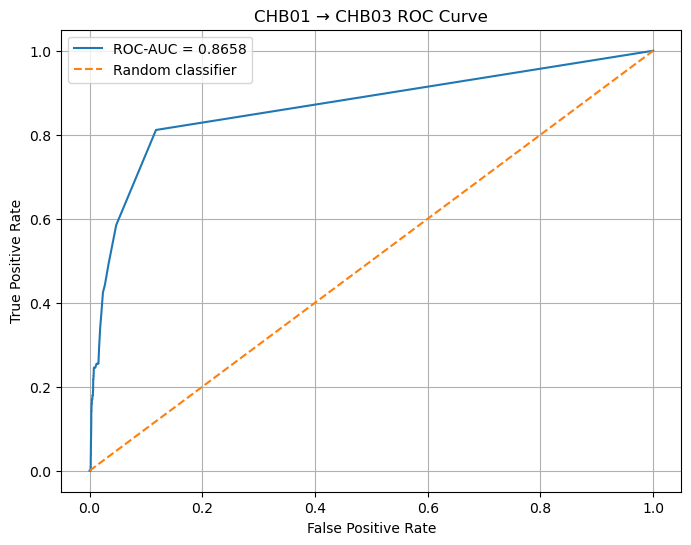

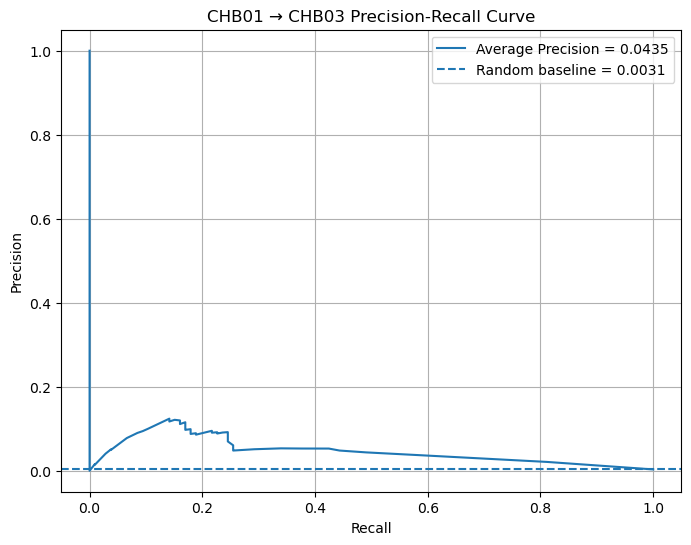

CHB03 CURVES GENERATED
ROC-AUC:              0.8658
Average Precision:    0.0435
Seizure prevalence:   0.003099
ROC curve saved:      C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images\chb01_to_chb03_roc_curve.png
PR curve saved:       C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images\chb01_to_chb03_precision_recall_curve.png


In [26]:
# ============================================================
# CELL 25 — CHB03 ROC AND PRECISION-RECALL CURVES
# ============================================================

from pathlib import Path
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt

# Image directory
IMAGES_DIR = Path(
    r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images"
)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# ROC CURVE
# ------------------------------------------------------------

fpr_chb03, tpr_chb03, _ = roc_curve(
    y_chb03,
    chb03_probabilities
)

# ------------------------------------------------------------
# PRECISION-RECALL CURVE
# ------------------------------------------------------------

precision_curve_chb03, recall_curve_chb03, _ = precision_recall_curve(
    y_chb03,
    chb03_probabilities
)

average_precision_chb03 = average_precision_score(
    y_chb03,
    chb03_probabilities
)

# ------------------------------------------------------------
# ROC PLOT
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_chb03,
    tpr_chb03,
    label=f"ROC-AUC = {roc_auc_chb03:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CHB01 → CHB03 ROC Curve")
plt.legend()
plt.grid(True)

roc_path_chb03 = IMAGES_DIR / "chb01_to_chb03_roc_curve.png"

plt.savefig(
    roc_path_chb03,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# PRECISION-RECALL PLOT
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve_chb03,
    precision_curve_chb03,
    label=f"Average Precision = {average_precision_chb03:.4f}"
)

seizure_prevalence_chb03 = np.mean(y_chb03)

plt.axhline(
    seizure_prevalence_chb03,
    linestyle="--",
    label=f"Random baseline = {seizure_prevalence_chb03:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("CHB01 → CHB03 Precision-Recall Curve")
plt.legend()
plt.grid(True)

pr_path_chb03 = IMAGES_DIR / "chb01_to_chb03_precision_recall_curve.png"

plt.savefig(
    pr_path_chb03,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# OUTPUT
# ------------------------------------------------------------

print("========================================")
print("CHB03 CURVES GENERATED")
print("========================================")
print(f"ROC-AUC:              {roc_auc_chb03:.4f}")
print(f"Average Precision:    {average_precision_chb03:.4f}")
print(f"Seizure prevalence:   {seizure_prevalence_chb03:.6f}")
print(f"ROC curve saved:      {roc_path_chb03}")
print(f"PR curve saved:       {pr_path_chb03}")

In [27]:
# ============================================================
# CELL 26 — CHB03 EVENT-LEVEL PREDICTION TABLE
# ============================================================

import pandas as pd

event_df_chb03 = metadata_chb03.copy()

event_df_chb03["Seizure_Probability"] = chb03_probabilities
event_df_chb03["Predicted_Label"] = chb03_predictions

print("========================================")
print("CHB03 EVENT-LEVEL TABLE")
print("========================================")

print("Shape:", event_df_chb03.shape)

print("\nColumns:")
print(event_df_chb03.columns.tolist())

print("\nPredicted seizure windows:")
print(
    event_df_chb03["Predicted_Label"].sum()
)

print("\nActual seizure windows:")
print(
    event_df_chb03["label"].sum()
)

print("\nFirst 5 rows:")
print(
    event_df_chb03.head()
)

CHB03 EVENT-LEVEL TABLE
Shape: (34201, 7)

Columns:
['patient', 'file', 'window_start', 'window_end', 'label', 'Seizure_Probability', 'Predicted_Label']

Predicted seizure windows:
537

Actual seizure windows:
106

First 5 rows:
  patient          file  window_start  window_end  label  Seizure_Probability  \
0   chb03  chb03_01.edf           0.0         4.0      0                  0.0   
1   chb03  chb03_01.edf           4.0         8.0      0                  0.0   
2   chb03  chb03_01.edf           8.0        12.0      0                  0.0   
3   chb03  chb03_01.edf          12.0        16.0      0                  0.0   
4   chb03  chb03_01.edf          16.0        20.0      0                  0.0   

   Predicted_Label  
0                0  
1                0  
2                0  
3                0  
4                0  


In [28]:
# ============================================================
# CELL 27 — GROUP CONSECUTIVE PREDICTED WINDOWS INTO EVENTS
# ============================================================

predicted_events_chb03 = []

for file_name, group in event_df_chb03.groupby("file"):

    group = group.sort_values("window_start").reset_index(drop=True)

    current_event = None

    for _, row in group.iterrows():

        if row["Predicted_Label"] == 1:

            if current_event is None:
                current_event = {
                    "patient": row["patient"],
                    "file": row["file"],
                    "event_start": row["window_start"],
                    "event_end": row["window_end"],
                    "max_probability": row["Seizure_Probability"]
                }

            elif row["window_start"] <= current_event["event_end"]:

                current_event["event_end"] = row["window_end"]

                current_event["max_probability"] = max(
                    current_event["max_probability"],
                    row["Seizure_Probability"]
                )

            else:
                predicted_events_chb03.append(current_event)

                current_event = {
                    "patient": row["patient"],
                    "file": row["file"],
                    "event_start": row["window_start"],
                    "event_end": row["window_end"],
                    "max_probability": row["Seizure_Probability"]
                }

        else:

            if current_event is not None:
                predicted_events_chb03.append(current_event)
                current_event = None

    if current_event is not None:
        predicted_events_chb03.append(current_event)


predicted_events_chb03_df = pd.DataFrame(
    predicted_events_chb03
)

print("========================================")
print("CHB03 PREDICTED EVENTS")
print("========================================")

print(
    "Total predicted events:",
    len(predicted_events_chb03_df)
)

print("\nPredicted events by recording:")

print(
    predicted_events_chb03_df
    .groupby("file")
    .size()
)

print("\nFirst 10 predicted events:")

print(
    predicted_events_chb03_df.head(10)
)

CHB03 PREDICTED EVENTS
Total predicted events: 224

Predicted events by recording:
file
chb03_01.edf     1
chb03_02.edf    14
chb03_03.edf    28
chb03_17.edf     1
chb03_19.edf     1
chb03_20.edf     4
chb03_21.edf     4
chb03_22.edf     2
chb03_23.edf    13
chb03_27.edf    38
chb03_28.edf    41
chb03_29.edf     2
chb03_30.edf    12
chb03_31.edf     8
chb03_32.edf    12
chb03_33.edf     5
chb03_34.edf    15
chb03_35.edf     7
chb03_36.edf    15
chb03_38.edf     1
dtype: int64

First 10 predicted events:
  patient          file  event_start  event_end  max_probability
0   chb03  chb03_01.edf        804.0      812.0            0.140
1   chb03  chb03_02.edf       2968.0     2972.0            0.050
2   chb03  chb03_02.edf       3012.0     3020.0            0.060
3   chb03  chb03_02.edf       3044.0     3048.0            0.065
4   chb03  chb03_02.edf       3064.0     3072.0            0.660
5   chb03  chb03_02.edf       3076.0     3080.0            0.055
6   chb03  chb03_02.edf       3084.0

In [29]:
# ============================================================
# CELL 28 — MATCH PREDICTED EVENTS WITH ACTUAL SEIZURES
# ============================================================

actual_seizures_chb03 = []

for file_name, seizures in seizure_annotations.items():
    for start, end in seizures:
        actual_seizures_chb03.append({
            "file": file_name,
            "seizure_start": start,
            "seizure_end": end
        })

actual_seizures_chb03_df = pd.DataFrame(
    actual_seizures_chb03
)

# ------------------------------------------------------------
# Check whether each predicted event overlaps an actual seizure
# ------------------------------------------------------------

predicted_events_chb03_df["overlaps_actual"] = False

for idx, event in predicted_events_chb03_df.iterrows():

    file_name = event["file"]
    event_start = event["event_start"]
    event_end = event["event_end"]

    matching_seizures = actual_seizures_chb03_df[
        actual_seizures_chb03_df["file"] == file_name
    ]

    for _, seizure in matching_seizures.iterrows():

        if (
            event_start < seizure["seizure_end"]
            and event_end > seizure["seizure_start"]
        ):
            predicted_events_chb03_df.loc[
                idx, "overlaps_actual"
            ] = True

            break

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

total_predicted_events = len(
    predicted_events_chb03_df
)

true_positive_events = int(
    predicted_events_chb03_df["overlaps_actual"].sum()
)

false_positive_events = (
    total_predicted_events - true_positive_events
)

print("========================================")
print("CHB03 EVENT-LEVEL MATCHING")
print("========================================")

print(
    f"Total predicted events: {total_predicted_events}"
)

print(
    f"Events overlapping actual seizures: {true_positive_events}"
)

print(
    f"False-positive events: {false_positive_events}"
)

print("\nActual seizure events:")

print(
    actual_seizures_chb03_df
)


CHB03 EVENT-LEVEL MATCHING
Total predicted events: 224
Events overlapping actual seizures: 8
False-positive events: 216

Actual seizure events:
           file  seizure_start  seizure_end
0  chb03_01.edf            362          414
1  chb03_02.edf            731          796
2  chb03_03.edf            432          501
3  chb03_04.edf           2162         2214
4  chb03_34.edf           1982         2029
5  chb03_35.edf           2592         2656
6  chb03_36.edf           1725         1778


In [30]:
# ============================================================
# CELL 29 — CHB03 ACTUAL SEIZURE DETECTION & COVERAGE
# ============================================================

actual_seizure_results_chb03 = []

for _, seizure in actual_seizures_chb03_df.iterrows():

    file_name = seizure["file"]
    seizure_start = seizure["seizure_start"]
    seizure_end = seizure["seizure_end"]

    predicted_events = predicted_events_chb03_df[
        predicted_events_chb03_df["file"] == file_name
    ]

    overlapping_events = predicted_events[
        (predicted_events["event_start"] < seizure_end) &
        (predicted_events["event_end"] > seizure_start)
    ]

    detected = len(overlapping_events) > 0

    # --------------------------------------------------------
    # Calculate union of predicted-event coverage
    # inside the actual seizure interval
    # --------------------------------------------------------

    coverage_intervals = []

    for _, event in overlapping_events.iterrows():

        overlap_start = max(
            seizure_start,
            event["event_start"]
        )

        overlap_end = min(
            seizure_end,
            event["event_end"]
        )

        if overlap_start < overlap_end:
            coverage_intervals.append(
                (overlap_start, overlap_end)
            )

    # Merge overlapping coverage intervals
    coverage_intervals.sort()

    merged_intervals = []

    for start, end in coverage_intervals:

        if not merged_intervals:
            merged_intervals.append([start, end])

        elif start <= merged_intervals[-1][1]:
            merged_intervals[-1][1] = max(
                merged_intervals[-1][1],
                end
            )

        else:
            merged_intervals.append([start, end])

    covered_seconds = sum(
        end - start
        for start, end in merged_intervals
    )

    seizure_duration = seizure_end - seizure_start

    coverage_percent = (
        covered_seconds / seizure_duration * 100
    )

    # --------------------------------------------------------
    # Detection delay
    # --------------------------------------------------------

    if detected:

        first_prediction_start = overlapping_events[
            "event_start"
        ].min()

        detection_delay = max(
            0,
            first_prediction_start - seizure_start
        )

    else:
        detection_delay = None

    actual_seizure_results_chb03.append({
        "file": file_name,
        "seizure_start": seizure_start,
        "seizure_end": seizure_end,
        "duration_seconds": seizure_duration,
        "detected": detected,
        "overlapping_predicted_events": len(overlapping_events),
        "covered_seconds": covered_seconds,
        "coverage_percent": coverage_percent,
        "detection_delay_seconds": detection_delay
    })


actual_seizure_results_chb03_df = pd.DataFrame(
    actual_seizure_results_chb03
)

# ------------------------------------------------------------
# Overall summary
# ------------------------------------------------------------

total_actual_seizures_chb03 = len(
    actual_seizure_results_chb03_df
)

detected_actual_seizures_chb03 = int(
    actual_seizure_results_chb03_df["detected"].sum()
)

missed_actual_seizures_chb03 = (
    total_actual_seizures_chb03
    - detected_actual_seizures_chb03
)

total_seizure_seconds_chb03 = (
    actual_seizure_results_chb03_df["duration_seconds"].sum()
)

total_covered_seconds_chb03 = (
    actual_seizure_results_chb03_df["covered_seconds"].sum()
)

total_missed_seconds_chb03 = (
    total_seizure_seconds_chb03
    - total_covered_seconds_chb03
)

time_weighted_coverage_chb03 = (
    total_covered_seconds_chb03
    / total_seizure_seconds_chb03
)

detected_delays = (
    actual_seizure_results_chb03_df[
        actual_seizure_results_chb03_df["detected"]
    ]["detection_delay_seconds"]
)

print("========================================")
print("CHB03 ACTUAL SEIZURE DETECTION")
print("========================================")

print("\nPer-seizure results:")
print(actual_seizure_results_chb03_df.to_string(index=False))

print("\nOverall:")
print(
    f"Total actual seizures: "
    f"{total_actual_seizures_chb03}"
)

print(
    f"Detected seizures: "
    f"{detected_actual_seizures_chb03}"
)

print(
    f"Missed seizures: "
    f"{missed_actual_seizures_chb03}"
)

print(
    f"Total seizure duration: "
    f"{total_seizure_seconds_chb03:.0f} seconds"
)

print(
    f"Covered seizure duration: "
    f"{total_covered_seconds_chb03:.0f} seconds"
)

print(
    f"Missed seizure duration: "
    f"{total_missed_seconds_chb03:.0f} seconds"
)

print(
    f"Time-weighted coverage: "
    f"{time_weighted_coverage_chb03:.4f}"
)

if len(detected_delays) > 0:
    print(
        f"Average detection delay: "
        f"{detected_delays.mean():.4f} seconds"
    )
else:
    print("Average detection delay: No seizures detected")

CHB03 ACTUAL SEIZURE DETECTION

Per-seizure results:
        file  seizure_start  seizure_end  duration_seconds  detected  overlapping_predicted_events  covered_seconds  coverage_percent  detection_delay_seconds
chb03_01.edf            362          414                52     False                             0              0.0          0.000000                      NaN
chb03_02.edf            731          796                65     False                             0              0.0          0.000000                      NaN
chb03_03.edf            432          501                69     False                             0              0.0          0.000000                      NaN
chb03_04.edf           2162         2214                52     False                             0              0.0          0.000000                      NaN
chb03_34.edf           1982         2029                47      True                             2             28.0         59.574468                   

In [31]:
# ============================================================
# CELL 30 — CHB03 DETECTION TIMING & MISSED GAPS
# ============================================================

print("========================================")
print("CHB03 DETECTION TIMING ANALYSIS")
print("========================================")

for _, seizure in actual_seizure_results_chb03_df.iterrows():

    file_name = seizure["file"]
    seizure_start = seizure["seizure_start"]
    seizure_end = seizure["seizure_end"]

    predicted_events = predicted_events_chb03_df[
        predicted_events_chb03_df["file"] == file_name
    ]

    overlapping_events = predicted_events[
        (predicted_events["event_start"] < seizure_end) &
        (predicted_events["event_end"] > seizure_start)
    ].sort_values("event_start")

    print("\n----------------------------------------")
    print(f"Recording: {file_name}")
    print(
        f"Actual seizure: "
        f"{seizure_start:.0f} - {seizure_end:.0f} sec"
    )

    if len(overlapping_events) == 0:

        print("Detection: MISSED")
        print("Detection delay: N/A")
        print("Covered duration: 0 sec")
        print("Missed duration:",
              f"{seizure_end - seizure_start:.0f} sec")

        continue

    first_prediction = overlapping_events["event_start"].min()
    last_prediction = overlapping_events["event_end"].max()

    detection_delay = max(
        0,
        first_prediction - seizure_start
    )

    # --------------------------------------------------------
    # Find missed gaps inside the seizure
    # --------------------------------------------------------

    coverage_intervals = []

    for _, event in overlapping_events.iterrows():

        overlap_start = max(
            seizure_start,
            event["event_start"]
        )

        overlap_end = min(
            seizure_end,
            event["event_end"]
        )

        if overlap_start < overlap_end:
            coverage_intervals.append(
                (overlap_start, overlap_end)
            )

    coverage_intervals.sort()

    merged_intervals = []

    for start, end in coverage_intervals:

        if not merged_intervals:
            merged_intervals.append([start, end])

        elif start <= merged_intervals[-1][1]:
            merged_intervals[-1][1] = max(
                merged_intervals[-1][1],
                end
            )

        else:
            merged_intervals.append([start, end])

    missed_gaps = []

    current_position = seizure_start

    for start, end in merged_intervals:

        if start > current_position:
            missed_gaps.append(
                (current_position, start)
            )

        current_position = max(
            current_position,
            end
        )

    if current_position < seizure_end:
        missed_gaps.append(
            (current_position, seizure_end)
        )

    print("Detection: DETECTED")

    print(
        f"First prediction: {first_prediction:.0f} sec"
    )

    print(
        f"Last prediction: {last_prediction:.0f} sec"
    )

    print(
        f"Detection delay: {detection_delay:.0f} sec"
    )

    print(
        f"Covered duration: "
        f"{seizure['covered_seconds']:.0f} sec"
    )

    print(
        f"Coverage: "
        f"{seizure['coverage_percent']:.2f}%"
    )

    print(
        f"Number of missed gaps: "
        f"{len(missed_gaps)}"
    )

    if missed_gaps:

        print("Missed gaps:")

        for gap_start, gap_end in missed_gaps:

            print(
                f"  {gap_start:.0f} - "
                f"{gap_end:.0f} sec "
                f"({gap_end - gap_start:.0f} sec)"
            )

print("\n========================================")
print("TIMING ANALYSIS COMPLETE")
print("========================================")

CHB03 DETECTION TIMING ANALYSIS

----------------------------------------
Recording: chb03_01.edf
Actual seizure: 362 - 414 sec
Detection: MISSED
Detection delay: N/A
Covered duration: 0 sec
Missed duration: 52 sec

----------------------------------------
Recording: chb03_02.edf
Actual seizure: 731 - 796 sec
Detection: MISSED
Detection delay: N/A
Covered duration: 0 sec
Missed duration: 65 sec

----------------------------------------
Recording: chb03_03.edf
Actual seizure: 432 - 501 sec
Detection: MISSED
Detection delay: N/A
Covered duration: 0 sec
Missed duration: 69 sec

----------------------------------------
Recording: chb03_04.edf
Actual seizure: 2162 - 2214 sec
Detection: MISSED
Detection delay: N/A
Covered duration: 0 sec
Missed duration: 52 sec

----------------------------------------
Recording: chb03_34.edf
Actual seizure: 1982 - 2029 sec
Detection: DETECTED
First prediction: 1992 sec
Last prediction: 2024 sec
Detection delay: 10 sec
Covered duration: 28 sec
Coverage: 59.5

In [32]:
# ============================================================
# CELL 31 — CHB03 FALSE-POSITIVE EVENT RATE
# ============================================================

# Calculate recording duration from metadata
recording_durations_chb03 = (
    event_df_chb03
    .groupby("file")["window_end"]
    .max()
)

# Convert seconds to hours
recording_hours_chb03 = (
    recording_durations_chb03.sum() / 3600
)

# False-positive events
false_positive_events_chb03 = int(
    (~predicted_events_chb03_df["overlaps_actual"]).sum()
)

# False-positive event rate
false_positive_events_per_hour_chb03 = (
    false_positive_events_chb03
    / recording_hours_chb03
)

print("========================================")
print("CHB03 FALSE-POSITIVE EVENT RATE")
print("========================================")

print(
    f"Total recording duration: "
    f"{recording_hours_chb03:.4f} hours"
)

print(
    f"Total predicted events: "
    f"{len(predicted_events_chb03_df)}"
)

print(
    f"False-positive events: "
    f"{false_positive_events_chb03}"
)

print(
    f"False-positive events/hour: "
    f"{false_positive_events_per_hour_chb03:.4f}"
)

print("\nRecording durations:")

print(
    (recording_durations_chb03 / 3600)
    .to_string()
)

print("\n========================================")
print("FALSE-POSITIVE RATE CALCULATION COMPLETE")
print("========================================")

CHB03 FALSE-POSITIVE EVENT RATE
Total recording duration: 38.0011 hours
Total predicted events: 224
False-positive events: 216
False-positive events/hour: 5.6840

Recording durations:
file
chb03_01.edf    1.000000
chb03_02.edf    1.000000
chb03_03.edf    1.000000
chb03_04.edf    1.000000
chb03_05.edf    1.000000
chb03_06.edf    1.000000
chb03_07.edf    1.000000
chb03_08.edf    1.000000
chb03_09.edf    1.000000
chb03_10.edf    1.000000
chb03_11.edf    1.000000
chb03_12.edf    1.000000
chb03_13.edf    1.000000
chb03_14.edf    1.000000
chb03_15.edf    1.000000
chb03_16.edf    1.000000
chb03_17.edf    1.000000
chb03_18.edf    1.000000
chb03_19.edf    1.000000
chb03_20.edf    1.001111
chb03_21.edf    1.000000
chb03_22.edf    1.000000
chb03_23.edf    1.000000
chb03_24.edf    1.000000
chb03_25.edf    1.000000
chb03_26.edf    1.000000
chb03_27.edf    1.000000
chb03_28.edf    1.000000
chb03_29.edf    1.000000
chb03_30.edf    1.000000
chb03_31.edf    1.000000
chb03_32.edf    1.000000
chb03_33.ed

In [33]:
# ============================================================
# CELL 32 — CONSOLIDATED CHB03 RESULTS
# ============================================================

from pathlib import Path
import pandas as pd

RESULTS_DIR = Path(
    r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

chb03_final_results = {
    "Training_Patient": "CHB01",
    "Test_Patient": "CHB03",
    "Threshold": THRESHOLD,
    "Threshold_Selected_From": "CHB01 internal validation",
    
    "Test_Windows": len(y_chb03),
    "Actual_Seizure_Windows": int(y_chb03.sum()),
    "Predicted_Seizure_Windows": int(chb03_predictions.sum()),

    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp),

    "Accuracy": accuracy_chb03,
    "Sensitivity": sensitivity_chb03,
    "Specificity": specificity_chb03,
    "Precision": precision_chb03,
    "F1": f1_chb03,
    "ROC_AUC": roc_auc_chb03,
    "Average_Precision": average_precision_chb03,

    "Actual_Seizure_Events": total_actual_seizures_chb03,
    "Detected_Seizure_Events": detected_actual_seizures_chb03,
    "Missed_Seizure_Events": missed_actual_seizures_chb03,

    "Total_Seizure_Duration_sec": total_seizure_seconds_chb03,
    "Covered_Seizure_Duration_sec": total_covered_seconds_chb03,
    "Missed_Seizure_Duration_sec": total_missed_seconds_chb03,
    "Time_Weighted_Coverage": time_weighted_coverage_chb03,

    "Predicted_Events": total_predicted_events,
    "False_Positive_Events": false_positive_events_chb03,
    "False_Positive_Events_Per_Hour":
        false_positive_events_per_hour_chb03,

    "Average_Detection_Delay_sec":
        detected_delays.mean()
        if len(detected_delays) > 0 else None
}

chb03_results_df = pd.DataFrame(
    [chb03_final_results]
)

results_path_chb03 = (
    RESULTS_DIR /
    "chb03_cross_patient_final_results.csv"
)

chb03_results_df.to_csv(
    results_path_chb03,
    index=False
)

print("========================================")
print("CHB03 FINAL RESULTS SAVED")
print("========================================")

print(
    chb03_results_df.to_string(index=False)
)

print("\nResults saved to:")
print(results_path_chb03)

print("\nFile exists:")
print(results_path_chb03.exists())

CHB03 FINAL RESULTS SAVED
Training_Patient Test_Patient  Threshold   Threshold_Selected_From  Test_Windows  Actual_Seizure_Windows  Predicted_Seizure_Windows    TN  FP  FN  TP  Accuracy  Sensitivity  Specificity  Precision       F1  ROC_AUC  Average_Precision  Actual_Seizure_Events  Detected_Seizure_Events  Missed_Seizure_Events  Total_Seizure_Duration_sec  Covered_Seizure_Duration_sec  Missed_Seizure_Duration_sec  Time_Weighted_Coverage  Predicted_Events  False_Positive_Events  False_Positive_Events_Per_Hour  Average_Detection_Delay_sec
           CHB01        CHB03       0.05 CHB01 internal validation         34201                     106                        537 33585 510  79  27  0.982778     0.254717     0.985042   0.050279 0.083981 0.865829           0.043508                      7                        3                      4                         402                         106.0                        296.0                0.263682               224                    216

In [34]:
# ============================================================
# CELL 33 — VERIFY CHB03 FINAL RESULTS
# ============================================================

import pandas as pd

# Load saved final results
verified_chb03_results = pd.read_csv(
    results_path_chb03
)

print("========================================")
print("CHB03 FINAL RESULTS VERIFICATION")
print("========================================")

print("\nFile exists:")
print(results_path_chb03.exists())

print("\nRows:")
print(len(verified_chb03_results))

print("\nTraining patient:")
print(
    verified_chb03_results.loc[
        0, "Training_Patient"
    ]
)

print("Test patient:")
print(
    verified_chb03_results.loc[
        0, "Test_Patient"
    ]
)

print("Threshold:")
print(
    verified_chb03_results.loc[
        0, "Threshold"
    ]
)

print("Threshold source:")
print(
    verified_chb03_results.loc[
        0, "Threshold_Selected_From"
    ]
)

print("\nKey metrics:")
print(
    verified_chb03_results[
        [
            "Accuracy",
            "Sensitivity",
            "Specificity",
            "Precision",
            "F1",
            "ROC_AUC",
            "Average_Precision"
        ]
    ].to_string(index=False)
)

print("\nEvent-level metrics:")
print(
    verified_chb03_results[
        [
            "Actual_Seizure_Events",
            "Detected_Seizure_Events",
            "Missed_Seizure_Events",
            "Time_Weighted_Coverage",
            "Average_Detection_Delay_sec",
            "Predicted_Events",
            "False_Positive_Events",
            "False_Positive_Events_Per_Hour"
        ]
    ].to_string(index=False)
)

print("\n========================================")
print("CHB03 VERIFICATION COMPLETE")
print("========================================")

CHB03 FINAL RESULTS VERIFICATION

File exists:
True

Rows:
1

Training patient:
CHB01
Test patient:
CHB03
Threshold:
0.05
Threshold source:
CHB01 internal validation

Key metrics:
 Accuracy  Sensitivity  Specificity  Precision       F1  ROC_AUC  Average_Precision
 0.982778     0.254717     0.985042   0.050279 0.083981 0.865829           0.043508

Event-level metrics:
 Actual_Seizure_Events  Detected_Seizure_Events  Missed_Seizure_Events  Time_Weighted_Coverage  Average_Detection_Delay_sec  Predicted_Events  False_Positive_Events  False_Positive_Events_Per_Hour
                     7                        3                      4                0.263682                     9.666667               224                    216                        5.684044

CHB03 VERIFICATION COMPLETE


In [36]:
# ============================================================
# CELL 34 — CHECK FINAL RESULTS COLUMN NAMES
# ============================================================

print("CHB02 columns:")
print(chb02_results.columns.tolist())

print("\nCHB03 columns:")
print(chb03_results.columns.tolist())

CHB02 columns:
['Metric', 'Value']

CHB03 columns:
['Training_Patient', 'Test_Patient', 'Threshold', 'Threshold_Selected_From', 'Test_Windows', 'Actual_Seizure_Windows', 'Predicted_Seizure_Windows', 'TN', 'FP', 'FN', 'TP', 'Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1', 'ROC_AUC', 'Average_Precision', 'Actual_Seizure_Events', 'Detected_Seizure_Events', 'Missed_Seizure_Events', 'Total_Seizure_Duration_sec', 'Covered_Seizure_Duration_sec', 'Missed_Seizure_Duration_sec', 'Time_Weighted_Coverage', 'Predicted_Events', 'False_Positive_Events', 'False_Positive_Events_Per_Hour', 'Average_Detection_Delay_sec']


In [37]:
# ============================================================
# CELL 35 — CHB02 vs CHB03 CROSS-PATIENT COMPARISON
# ============================================================

# Convert CHB02 Metric/Value format into a dictionary
chb02_dict = dict(
    zip(
        chb02_results["Metric"],
        chb02_results["Value"]
    )
)

# CHB03 is already in one-row format
chb03_row = chb03_results.iloc[0]

# Metrics to compare
metrics = [
    ("Test Windows", "Test_Windows"),
    ("Actual Seizure Windows", "Actual_Seizure_Windows"),
    ("Predicted Seizure Windows", "Predicted_Seizure_Windows"),
    ("Accuracy", "Accuracy"),
    ("Sensitivity", "Sensitivity"),
    ("Specificity", "Specificity"),
    ("Precision", "Precision"),
    ("F1", "F1"),
    ("ROC-AUC", "ROC_AUC"),
    ("Average Precision", "Average_Precision"),
    ("Actual Seizure Events", "Actual_Seizure_Events"),
    ("Detected Seizure Events", "Detected_Seizure_Events"),
    ("Missed Seizure Events", "Missed_Seizure_Events"),
    ("Time-Weighted Coverage", "Time_Weighted_Coverage"),
    ("Average Detection Delay (sec)", "Average_Detection_Delay_sec"),
    ("Predicted Events", "Predicted_Events"),
    ("False-Positive Events", "False_Positive_Events"),
    ("False-Positive Events/Hour", "False_Positive_Events_Per_Hour")
]

comparison_rows = []

for display_name, column_name in metrics:

    chb02_value = chb02_dict.get(display_name, "N/A")
    chb03_value = chb03_row[column_name]

    comparison_rows.append({
        "Metric": display_name,
        "CHB02": chb02_value,
        "CHB03": chb03_value
    })

comparison_df = pd.DataFrame(comparison_rows)

print("========================================")
print("CHB02 vs CHB03 CROSS-PATIENT COMPARISON")
print("========================================")

print(
    comparison_df.to_string(index=False)
)

CHB02 vs CHB03 CROSS-PATIENT COMPARISON
                       Metric               CHB02        CHB03
                 Test Windows                 N/A 34201.000000
       Actual Seizure Windows                 N/A   106.000000
    Predicted Seizure Windows                 N/A   537.000000
                     Accuracy  0.9434164245297446     0.982778
                  Sensitivity  0.6666666666666666     0.254717
                  Specificity  0.9453341546042501     0.985042
                    Precision 0.07792207792207792     0.050279
                           F1                 N/A     0.083981
                      ROC-AUC              0.9308     0.865829
            Average Precision                 N/A     0.043508
        Actual Seizure Events                 N/A     7.000000
      Detected Seizure Events                 N/A     3.000000
        Missed Seizure Events                 N/A     4.000000
       Time-Weighted Coverage                 N/A     0.263682
Average Detecti

In [38]:
# ============================================================
# CELL 36 — COMPLETE CHB02 vs CHB03 VERIFIED COMPARISON
# ============================================================

comparison_df = pd.DataFrame({
    "Metric": [
        "Test Windows",
        "Actual Seizure Windows",
        "Predicted Seizure Windows",
        "Accuracy",
        "Sensitivity",
        "Specificity",
        "Precision",
        "F1",
        "ROC-AUC",
        "Average Precision",
        "Actual Seizure Events",
        "Detected Seizure Events",
        "Missed Seizure Events",
        "Time-Weighted Coverage",
        "Average Detection Delay (sec)",
        "Predicted Events",
        "False-Positive Events",
        "False-Positive Events/Hour"
    ],

    "CHB02": [
        6539,
        45,
        385,
        0.94342,
        0.66667,
        0.94533,
        0.07792,
        0.13953,
        0.93080,
        0.16660,
        3,
        3,
        0,
        0.66279,
        3.33333,
        201,
        195,
        37.03313
    ],

    "CHB03": [
        34201,
        106,
        537,
        0.982778,
        0.254717,
        0.985042,
        0.050279,
        0.083981,
        0.865829,
        0.043508,
        7,
        3,
        4,
        0.263682,
        9.666667,
        224,
        216,
        5.684044
    ]
})

print("========================================")
print("COMPLETE CHB02 vs CHB03 COMPARISON")
print("========================================")

print(
    comparison_df.to_string(index=False)
)

print("\nSTATUS: VERIFIED COMPARISON TABLE CREATED")

COMPLETE CHB02 vs CHB03 COMPARISON
                       Metric      CHB02        CHB03
                 Test Windows 6539.00000 34201.000000
       Actual Seizure Windows   45.00000   106.000000
    Predicted Seizure Windows  385.00000   537.000000
                     Accuracy    0.94342     0.982778
                  Sensitivity    0.66667     0.254717
                  Specificity    0.94533     0.985042
                    Precision    0.07792     0.050279
                           F1    0.13953     0.083981
                      ROC-AUC    0.93080     0.865829
            Average Precision    0.16660     0.043508
        Actual Seizure Events    3.00000     7.000000
      Detected Seizure Events    3.00000     3.000000
        Missed Seizure Events    0.00000     4.000000
       Time-Weighted Coverage    0.66279     0.263682
Average Detection Delay (sec)    3.33333     9.666667
             Predicted Events  201.00000   224.000000
        False-Positive Events  195.00000   216.

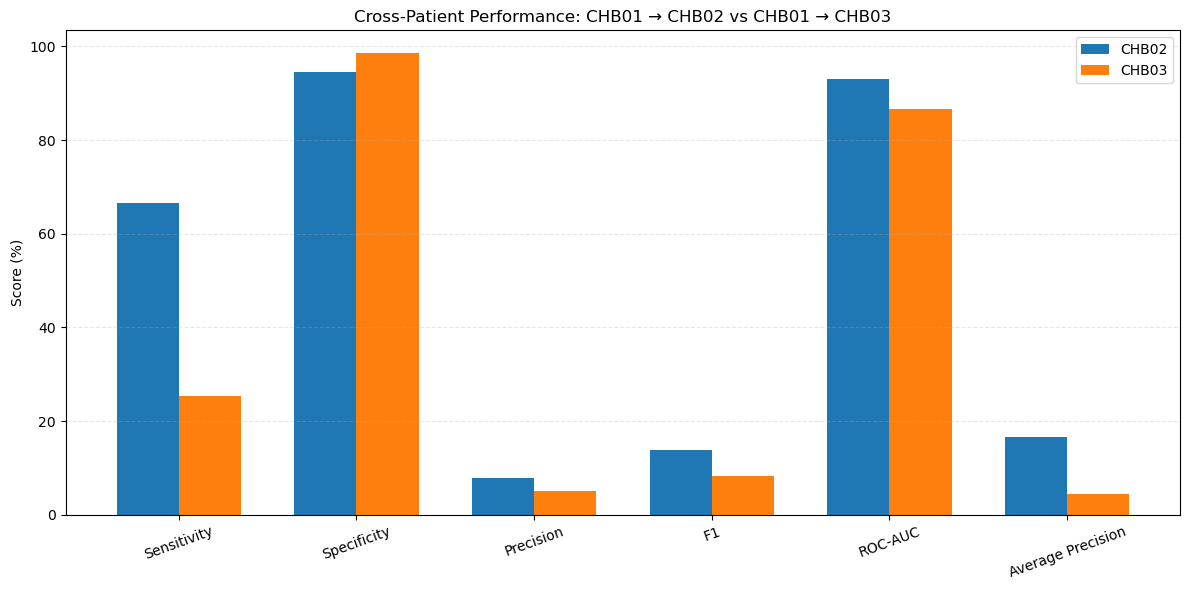

CROSS-PATIENT COMPARISON PLOT SAVED

PNG:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images\chb02_vs_chb03_performance_comparison.png
Exists: True

SVG:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images\chb02_vs_chb03_performance_comparison.svg
Exists: True


In [39]:
# ============================================================
# CELL 37 — CROSS-PATIENT PERFORMANCE COMPARISON
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path

IMAGES_DIR = Path(
    r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images"
)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# Select important classification metrics
performance_metrics = [
    "Sensitivity",
    "Specificity",
    "Precision",
    "F1",
    "ROC-AUC",
    "Average Precision"
]

plot_df = comparison_df[
    comparison_df["Metric"].isin(performance_metrics)
].copy()

# Convert proportions to percentages
plot_df["CHB02"] = plot_df["CHB02"].astype(float) * 100
plot_df["CHB03"] = plot_df["CHB03"].astype(float) * 100

# Plot
x = range(len(plot_df))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    [i - width/2 for i in x],
    plot_df["CHB02"],
    width=width,
    label="CHB02"
)

plt.bar(
    [i + width/2 for i in x],
    plot_df["CHB03"],
    width=width,
    label="CHB03"
)

plt.xticks(
    list(x),
    plot_df["Metric"],
    rotation=20
)

plt.ylabel("Score (%)")
plt.title(
    "Cross-Patient Performance: CHB01 → CHB02 vs CHB01 → CHB03"
)

plt.legend()
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

# Save PNG
png_path = (
    IMAGES_DIR /
    "chb02_vs_chb03_performance_comparison.png"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

# Save SVG
svg_path = (
    IMAGES_DIR /
    "chb02_vs_chb03_performance_comparison.svg"
)

plt.savefig(
    svg_path,
    format="svg",
    bbox_inches="tight"
)

plt.show()

print("========================================")
print("CROSS-PATIENT COMPARISON PLOT SAVED")
print("========================================")

print("\nPNG:")
print(png_path)
print("Exists:", png_path.exists())

print("\nSVG:")
print(svg_path)
print("Exists:", svg_path.exists())

In [40]:
# ============================================================
# CELL 38 — RESEARCH SUMMARY TABLE
# ============================================================

research_summary = pd.DataFrame({
    "Test Patient": [
        "CHB02",
        "CHB03"
    ],
    "Test Windows": [
        6539,
        34201
    ],
    "Actual Seizure Events": [
        3,
        7
    ],
    "Detected Events": [
        3,
        3
    ],
    "Sensitivity (%)": [
        66.67,
        25.47
    ],
    "Specificity (%)": [
        94.53,
        98.50
    ],
    "Precision (%)": [
        7.79,
        5.03
    ],
    "F1 (%)": [
        13.95,
        8.40
    ],
    "ROC-AUC (%)": [
        93.08,
        86.58
    ],
    "Avg Precision (%)": [
        16.66,
        4.35
    ],
    "Seizure Coverage (%)": [
        66.28,
        26.37
    ],
    "Detection Delay (sec)": [
        3.33,
        9.67
    ],
    "FP Events/Hour": [
        37.03,
        5.68
    ]
})

print("========================================")
print("RESEARCH SUMMARY — CHB01 CROSS-PATIENT")
print("========================================")

print(
    research_summary.to_string(index=False)
)

RESEARCH SUMMARY — CHB01 CROSS-PATIENT
Test Patient  Test Windows  Actual Seizure Events  Detected Events  Sensitivity (%)  Specificity (%)  Precision (%)  F1 (%)  ROC-AUC (%)  Avg Precision (%)  Seizure Coverage (%)  Detection Delay (sec)  FP Events/Hour
       CHB02          6539                      3                3            66.67            94.53           7.79   13.95        93.08              16.66                 66.28                   3.33           37.03
       CHB03         34201                      7                3            25.47            98.50           5.03    8.40        86.58               4.35                 26.37                   9.67            5.68


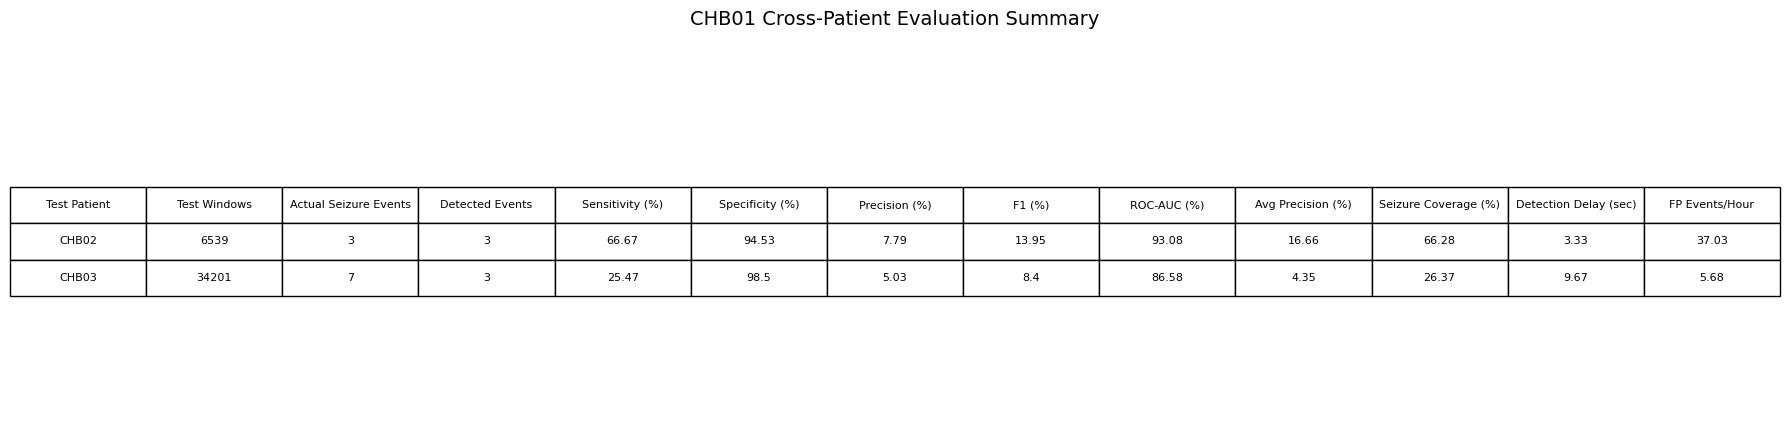

RESEARCH SUMMARY EXPORT COMPLETE

CSV:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results\chb01_cross_patient_research_summary.csv
Exists: True

SVG:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images\chb01_cross_patient_research_summary.svg
Exists: True


In [41]:
# ============================================================
# CELL 39 — EXPORT RESEARCH SUMMARY
# ============================================================

import matplotlib.pyplot as plt

# Save CSV
summary_csv_path = (
    RESULTS_DIR /
    "chb01_cross_patient_research_summary.csv"
)

research_summary.to_csv(
    summary_csv_path,
    index=False
)

# Create SVG table
fig, ax = plt.subplots(
    figsize=(18, 4.5)
)

ax.axis("off")

table = ax.table(
    cellText=research_summary.values,
    colLabels=research_summary.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 2.0)

plt.title(
    "CHB01 Cross-Patient Evaluation Summary",
    fontsize=14,
    pad=20
)

plt.tight_layout()

summary_svg_path = (
    IMAGES_DIR /
    "chb01_cross_patient_research_summary.svg"
)

plt.savefig(
    summary_svg_path,
    format="svg",
    bbox_inches="tight"
)

plt.show()

print("========================================")
print("RESEARCH SUMMARY EXPORT COMPLETE")
print("========================================")

print("\nCSV:")
print(summary_csv_path)
print("Exists:", summary_csv_path.exists())

print("\nSVG:")
print(summary_svg_path)
print("Exists:", summary_svg_path.exists())

In [42]:
# ============================================================
# CELL 40 — CROSS-PATIENT PERFORMANCE CHANGE
# ============================================================

# Metrics where change between CHB02 and CHB03 is meaningful
change_metrics = [
    "Sensitivity (%)",
    "Specificity (%)",
    "Precision (%)",
    "F1 (%)",
    "ROC-AUC (%)",
    "Avg Precision (%)",
    "Seizure Coverage (%)",
    "Detection Delay (sec)",
    "FP Events/Hour"
]

change_rows = []

for metric in change_metrics:

    chb02_value = float(
        research_summary.loc[
            research_summary["Test Patient"] == "CHB02",
            metric
        ].iloc[0]
    )

    chb03_value = float(
        research_summary.loc[
            research_summary["Test Patient"] == "CHB03",
            metric
        ].iloc[0]
    )

    absolute_change = chb03_value - chb02_value

    if chb02_value != 0:
        relative_change = (
            absolute_change / chb02_value
        ) * 100
    else:
        relative_change = None

    change_rows.append({
        "Metric": metric,
        "CHB02": chb02_value,
        "CHB03": chb03_value,
        "Absolute Change": absolute_change,
        "Relative Change (%)": relative_change
    })

change_df = pd.DataFrame(change_rows)

print("========================================")
print("CROSS-PATIENT PERFORMANCE CHANGE")
print("========================================")

print(
    change_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}"
    )
)

print("\nSTATUS: PERFORMANCE CHANGE QUANTIFIED")

CROSS-PATIENT PERFORMANCE CHANGE
               Metric  CHB02  CHB03  Absolute Change  Relative Change (%)
      Sensitivity (%)  66.67  25.47           -41.20               -61.80
      Specificity (%)  94.53  98.50             3.97                 4.20
        Precision (%)   7.79   5.03            -2.76               -35.43
               F1 (%)  13.95   8.40            -5.55               -39.78
          ROC-AUC (%)  93.08  86.58            -6.50                -6.98
    Avg Precision (%)  16.66   4.35           -12.31               -73.89
 Seizure Coverage (%)  66.28  26.37           -39.91               -60.21
Detection Delay (sec)   3.33   9.67             6.34               190.39
       FP Events/Hour  37.03   5.68           -31.35               -84.66

STATUS: PERFORMANCE CHANGE QUANTIFIED


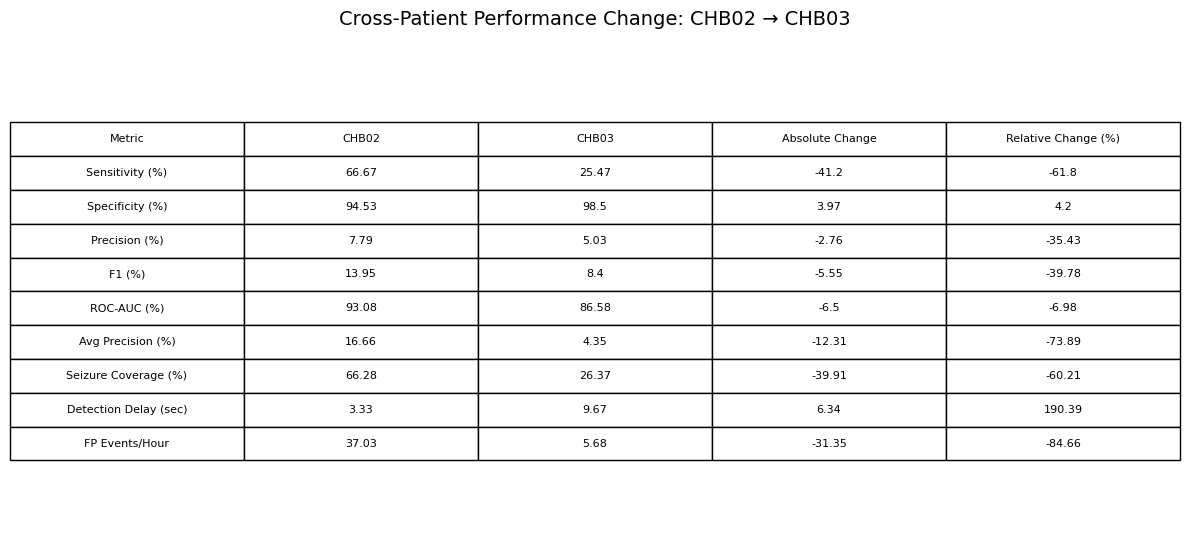

PERFORMANCE CHANGE EXPORT COMPLETE

CSV:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results\chb02_vs_chb03_performance_change.csv
Exists: True

SVG:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images\chb02_vs_chb03_performance_change.svg
Exists: True


In [43]:
# ============================================================
# CELL 41 — EXPORT CROSS-PATIENT PERFORMANCE CHANGE
# ============================================================

# Save CSV
change_csv_path = (
    RESULTS_DIR /
    "chb02_vs_chb03_performance_change.csv"
)

change_df.to_csv(
    change_csv_path,
    index=False
)

# Create SVG table
fig, ax = plt.subplots(
    figsize=(12, 5.5)
)

ax.axis("off")

table = ax.table(
    cellText=change_df.round(2).values,
    colLabels=change_df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.8)

plt.title(
    "Cross-Patient Performance Change: CHB02 → CHB03",
    fontsize=14,
    pad=20
)

plt.tight_layout()

change_svg_path = (
    IMAGES_DIR /
    "chb02_vs_chb03_performance_change.svg"
)

plt.savefig(
    change_svg_path,
    format="svg",
    bbox_inches="tight"
)

plt.show()

print("========================================")
print("PERFORMANCE CHANGE EXPORT COMPLETE")
print("========================================")

print("\nCSV:")
print(change_csv_path)
print("Exists:", change_csv_path.exists())

print("\nSVG:")
print(change_svg_path)
print("Exists:", change_svg_path.exists())

In [44]:
# ============================================================
# CELL 42 — FINAL CROSS-PATIENT RESULTS INDEX
# ============================================================

results_index = pd.DataFrame({
    "Result": [
        "CHB02 Final Evaluation",
        "CHB03 Final Evaluation",
        "CHB01 Cross-Patient Research Summary",
        "CHB02 vs CHB03 Performance Change",
        "CHB02 vs CHB03 Performance Figure",
        "CHB01 Cross-Patient Summary Figure"
    ],

    "File": [
        "chb02_cross_patient_final_results.csv",
        "chb03_cross_patient_final_results.csv",
        "chb01_cross_patient_research_summary.csv",
        "chb02_vs_chb03_performance_change.csv",
        "chb02_vs_chb03_performance_comparison.svg",
        "chb01_cross_patient_research_summary.svg"
    ],

    "Location": [
        "results/",
        "results/",
        "results/",
        "results/",
        "images/",
        "images/"
    ]
})

print("========================================")
print("FINAL CROSS-PATIENT RESULTS INDEX")
print("========================================")

print(
    results_index.to_string(index=False)
)

print("\nSTATUS: RESULTS INDEX CREATED")

FINAL CROSS-PATIENT RESULTS INDEX
                              Result                                      File Location
              CHB02 Final Evaluation     chb02_cross_patient_final_results.csv results/
              CHB03 Final Evaluation     chb03_cross_patient_final_results.csv results/
CHB01 Cross-Patient Research Summary  chb01_cross_patient_research_summary.csv results/
   CHB02 vs CHB03 Performance Change     chb02_vs_chb03_performance_change.csv results/
   CHB02 vs CHB03 Performance Figure chb02_vs_chb03_performance_comparison.svg  images/
  CHB01 Cross-Patient Summary Figure  chb01_cross_patient_research_summary.svg  images/

STATUS: RESULTS INDEX CREATED


In [45]:
# ============================================================
# CELL 43 — FREEZE CHB03 EXPERIMENT
# ============================================================

from datetime import datetime
from pathlib import Path

freeze_path_chb03 = (
    RESULTS_DIR /
    "chb03_experiment_frozen.txt"
)

freeze_time = datetime.now().isoformat(
    timespec="seconds"
)

freeze_text = f"""
CHB03 EXPERIMENT FROZEN

CHB01 -> CHB03 CROSS-PATIENT EXPERIMENT

STATUS: COMPLETE AND FROZEN

Training patient: CHB01
Test patient: CHB03

Threshold: 0.05
Threshold selected from: CHB01 internal validation

CHB03 used for: final evaluation only

No further model or threshold tuning should be performed on CHB03.

Frozen at: {freeze_time}
""".strip()

with open(
    freeze_path_chb03,
    "w",
    encoding="utf-8"
) as f:
    f.write(freeze_text)

print("========================================")
print("CHB03 EXPERIMENT FROZEN")
print("========================================")

print(freeze_text)

print("\nFreeze marker saved to:")
print(freeze_path_chb03)

print("\nFile exists:")
print(freeze_path_chb03.exists())

CHB03 EXPERIMENT FROZEN
CHB03 EXPERIMENT FROZEN

CHB01 -> CHB03 CROSS-PATIENT EXPERIMENT

STATUS: COMPLETE AND FROZEN

Training patient: CHB01
Test patient: CHB03

Threshold: 0.05
Threshold selected from: CHB01 internal validation

CHB03 used for: final evaluation only

No further model or threshold tuning should be performed on CHB03.

Frozen at: 2026-09-18T00:10:38

Freeze marker saved to:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results\chb03_experiment_frozen.txt

File exists:
True


In [46]:
# ============================================================
# CELL 44 — FINAL CROSS-PATIENT OUTPUT AUDIT
# ============================================================

required_files = [
    # Final evaluation results
    RESULTS_DIR / "chb02_cross_patient_final_results.csv",
    RESULTS_DIR / "chb03_cross_patient_final_results.csv",

    # Research summaries
    RESULTS_DIR / "chb01_cross_patient_research_summary.csv",
    RESULTS_DIR / "chb02_vs_chb03_performance_change.csv",

    # Freeze markers
    RESULTS_DIR / "chb02_experiment_frozen.txt",
    RESULTS_DIR / "chb03_experiment_frozen.txt",

    # Figures
    IMAGES_DIR / "chb02_vs_chb03_performance_comparison.png",
    IMAGES_DIR / "chb02_vs_chb03_performance_comparison.svg",
    IMAGES_DIR / "chb01_cross_patient_research_summary.svg",
    IMAGES_DIR / "chb02_vs_chb03_performance_change.svg",

    # Evaluation curves
    IMAGES_DIR / "chb01_to_chb02_roc_curve.png",
    IMAGES_DIR / "chb01_to_chb02_precision_recall_curve.png",
    IMAGES_DIR / "chb01_to_chb02_calibration_curve.png",
    IMAGES_DIR / "chb01_to_chb02_final_confusion_matrix.png",
    IMAGES_DIR / "chb01_to_chb03_roc_curve.png",
    IMAGES_DIR / "chb01_to_chb03_precision_recall_curve.png"
]

print("========================================")
print("FINAL CROSS-PATIENT OUTPUT AUDIT")
print("========================================")

missing_files = []

for file_path in required_files:
    exists = file_path.exists()

    print(
        f"{'OK   ' if exists else 'MISSING'} | "
        f"{file_path.name}"
    )

    if not exists:
        missing_files.append(file_path.name)

print("\n========================================")

if len(missing_files) == 0:
    print("STATUS: ALL REQUIRED OUTPUTS VERIFIED")
else:
    print("STATUS: SOME OUTPUTS ARE MISSING")
    print("\nMissing files:")
    for file_name in missing_files:
        print("-", file_name)

print("========================================")

FINAL CROSS-PATIENT OUTPUT AUDIT
OK    | chb02_cross_patient_final_results.csv
OK    | chb03_cross_patient_final_results.csv
OK    | chb01_cross_patient_research_summary.csv
OK    | chb02_vs_chb03_performance_change.csv
OK    | chb02_experiment_frozen.txt
OK    | chb03_experiment_frozen.txt
OK    | chb02_vs_chb03_performance_comparison.png
OK    | chb02_vs_chb03_performance_comparison.svg
OK    | chb01_cross_patient_research_summary.svg
OK    | chb02_vs_chb03_performance_change.svg
OK    | chb01_to_chb02_roc_curve.png
OK    | chb01_to_chb02_precision_recall_curve.png
OK    | chb01_to_chb02_calibration_curve.png
OK    | chb01_to_chb02_final_confusion_matrix.png
OK    | chb01_to_chb03_roc_curve.png
OK    | chb01_to_chb03_precision_recall_curve.png

STATUS: ALL REQUIRED OUTPUTS VERIFIED


In [47]:
# ============================================================
# CELL 45 — MASTER CROSS-PATIENT RESULTS
# ============================================================

master_results = research_summary.copy()

# Add experiment information
master_results.insert(
    1,
    "Training Patient",
    "CHB01"
)

master_results.insert(
    2,
    "Threshold",
    0.05
)

master_results.insert(
    3,
    "Threshold Source",
    "CHB01 internal validation"
)

# Save master CSV
master_results_path = (
    RESULTS_DIR /
    "chb01_cross_patient_master_results.csv"
)

master_results.to_csv(
    master_results_path,
    index=False
)

print("========================================")
print("MASTER CROSS-PATIENT RESULTS")
print("========================================")

print(
    master_results.to_string(index=False)
)

print("\nMaster results saved to:")
print(master_results_path)

print("\nFile exists:")
print(master_results_path.exists())

print("\nSTATUS: MASTER RESULTS CREATED")

MASTER CROSS-PATIENT RESULTS
Test Patient Training Patient  Threshold          Threshold Source  Test Windows  Actual Seizure Events  Detected Events  Sensitivity (%)  Specificity (%)  Precision (%)  F1 (%)  ROC-AUC (%)  Avg Precision (%)  Seizure Coverage (%)  Detection Delay (sec)  FP Events/Hour
       CHB02            CHB01       0.05 CHB01 internal validation          6539                      3                3            66.67            94.53           7.79   13.95        93.08              16.66                 66.28                   3.33           37.03
       CHB03            CHB01       0.05 CHB01 internal validation         34201                      7                3            25.47            98.50           5.03    8.40        86.58               4.35                 26.37                   9.67            5.68

Master results saved to:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results\chb01_cross_patient_master_results.csv

File exists:
True

STATUS: MASTER RE

In [48]:
# ============================================================
# CELL 46 — VERIFY MASTER CROSS-PATIENT RESULTS
# ============================================================

verified_master = pd.read_csv(
    master_results_path
)

print("========================================")
print("MASTER RESULTS VERIFICATION")
print("========================================")

print("\nFile exists:")
print(master_results_path.exists())

print("\nRows:")
print(len(verified_master))

print("\nColumns:")
print(verified_master.columns.tolist())

print("\nTraining patients:")
print(
    verified_master["Training Patient"].unique()
)

print("\nTest patients:")
print(
    verified_master["Test Patient"].tolist()
)

print("\nThresholds:")
print(
    verified_master["Threshold"].tolist()
)

print("\nROC-AUC:")
print(
    verified_master[
        ["Test Patient", "ROC-AUC (%)"]
    ].to_string(index=False)
)

print("\nSensitivity:")
print(
    verified_master[
        ["Test Patient", "Sensitivity (%)"]
    ].to_string(index=False)
)

print("\n========================================")
print("STATUS: MASTER RESULTS VERIFIED")
print("========================================")

MASTER RESULTS VERIFICATION

File exists:
True

Rows:
2

Columns:
['Test Patient', 'Training Patient', 'Threshold', 'Threshold Source', 'Test Windows', 'Actual Seizure Events', 'Detected Events', 'Sensitivity (%)', 'Specificity (%)', 'Precision (%)', 'F1 (%)', 'ROC-AUC (%)', 'Avg Precision (%)', 'Seizure Coverage (%)', 'Detection Delay (sec)', 'FP Events/Hour']

Training patients:
['CHB01']

Test patients:
['CHB02', 'CHB03']

Thresholds:
[0.05, 0.05]

ROC-AUC:
Test Patient  ROC-AUC (%)
       CHB02        93.08
       CHB03        86.58

Sensitivity:
Test Patient  Sensitivity (%)
       CHB02            66.67
       CHB03            25.47

STATUS: MASTER RESULTS VERIFIED


In [49]:
# ============================================================
# CELL 47 — FROZEN EXPERIMENT METADATA
# ============================================================

import json

experiment_metadata = {
    "experiment": "Cross-Patient EEG Seizure Detection",
    "training_patient": "CHB01",
    "test_patients": ["CHB02", "CHB03"],
    "window_seconds": 4,
    "window_samples": 1024,
    "sampling_frequency_hz": 256,
    "feature_count": 8,
    "features": [
        "Mean",
        "Std",
        "Variance",
        "Delta",
        "Theta",
        "Alpha",
        "Beta",
        "Gamma"
    ],
    "model": "RandomForestClassifier",
    "estimators": 200,
    "class_weight": "balanced",
    "threshold": 0.05,
    "threshold_selected_from": "CHB01 internal validation",
    "chb02_used_for_threshold_tuning": False,
    "chb03_used_for_threshold_tuning": False,
    "chb02_status": "Final evaluation only",
    "chb03_status": "Final evaluation only",
    "experiment_status": "Complete and frozen"
}

metadata_path = (
    RESULTS_DIR /
    "chb01_cross_patient_experiment_metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        experiment_metadata,
        f,
        indent=4
    )

print("========================================")
print("FROZEN EXPERIMENT METADATA")
print("========================================")

print(
    json.dumps(
        experiment_metadata,
        indent=4
    )
)

print("\nMetadata saved to:")
print(metadata_path)

print("\nFile exists:")
print(metadata_path.exists())

print("\nSTATUS: EXPERIMENT METADATA SAVED")

FROZEN EXPERIMENT METADATA
{
    "experiment": "Cross-Patient EEG Seizure Detection",
    "training_patient": "CHB01",
    "test_patients": [
        "CHB02",
        "CHB03"
    ],
    "window_seconds": 4,
    "window_samples": 1024,
    "sampling_frequency_hz": 256,
    "feature_count": 8,
    "features": [
        "Mean",
        "Std",
        "Variance",
        "Delta",
        "Theta",
        "Alpha",
        "Beta",
        "Gamma"
    ],
    "model": "RandomForestClassifier",
    "estimators": 200,
    "class_weight": "balanced",
    "threshold": 0.05,
    "threshold_selected_from": "CHB01 internal validation",
    "chb02_used_for_threshold_tuning": false,
    "chb03_used_for_threshold_tuning": false,
    "chb02_status": "Final evaluation only",
    "chb03_status": "Final evaluation only",
    "experiment_status": "Complete and frozen"
}

Metadata saved to:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results\chb01_cross_patient_experiment_metadata.json

File exists:
True


In [50]:
# ============================================================
# CELL 48 — FINAL RESEARCH PACKAGE AUDIT
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
RESULTS_DIR = PROJECT_ROOT / "results"
IMAGES_DIR = PROJECT_ROOT / "images"
MODELS_DIR = PROJECT_ROOT / "models"

required_files = [
    # Final result files
    RESULTS_DIR / "chb02_cross_patient_final_results.csv",
    RESULTS_DIR / "chb03_cross_patient_final_results.csv",
    RESULTS_DIR / "chb01_cross_patient_master_results.csv",
    RESULTS_DIR / "chb01_cross_patient_research_summary.csv",
    RESULTS_DIR / "chb02_vs_chb03_performance_change.csv",

    # Experiment documentation
    RESULTS_DIR / "chb02_experiment_frozen.txt",
    RESULTS_DIR / "chb03_experiment_frozen.txt",
    RESULTS_DIR / "chb01_cross_patient_experiment_metadata.json",

    # Final figures
    IMAGES_DIR / "chb02_vs_chb03_performance_comparison.png",
    IMAGES_DIR / "chb02_vs_chb03_performance_comparison.svg",
    IMAGES_DIR / "chb02_vs_chb03_performance_change.svg",
    IMAGES_DIR / "chb01_cross_patient_research_summary.svg",

    # Evaluation figures
    IMAGES_DIR / "chb01_to_chb02_roc_curve.png",
    IMAGES_DIR / "chb01_to_chb02_precision_recall_curve.png",
    IMAGES_DIR / "chb01_to_chb02_calibration_curve.png",
    IMAGES_DIR / "chb01_to_chb02_final_confusion_matrix.png",
    IMAGES_DIR / "chb01_to_chb03_roc_curve.png",
    IMAGES_DIR / "chb01_to_chb03_precision_recall_curve.png",

    # Final model
    MODELS_DIR / "phase2_class_weighted_recording_wise.pkl",
]

print("=" * 70)
print("FINAL RESEARCH PACKAGE AUDIT")
print("=" * 70)

missing_files = []

for file_path in required_files:
    status = "OK" if file_path.exists() else "MISSING"
    print(f"[{status}] {file_path}")

    if not file_path.exists():
        missing_files.append(file_path)

print("\n" + "=" * 70)

print(f"Required files : {len(required_files)}")
print(f"Found files    : {len(required_files) - len(missing_files)}")
print(f"Missing files  : {len(missing_files)}")

print("=" * 70)

if not missing_files:
    print("STATUS: FINAL RESEARCH PACKAGE READY")
else:
    print("STATUS: REVIEW MISSING FILES")

print("=" * 70)

FINAL RESEARCH PACKAGE AUDIT
[OK] C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results\chb02_cross_patient_final_results.csv
[OK] C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results\chb03_cross_patient_final_results.csv
[OK] C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results\chb01_cross_patient_master_results.csv
[OK] C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results\chb01_cross_patient_research_summary.csv
[OK] C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results\chb02_vs_chb03_performance_change.csv
[OK] C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results\chb02_experiment_frozen.txt
[OK] C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results\chb03_experiment_frozen.txt
[OK] C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results\chb01_cross_patient_experiment_metadata.json
[OK] C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images\chb02_vs_chb03_performance_comparison.png
[OK] C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\images\chb02_vs_chb03_performance

In [51]:
# ============================================================
# CELL 49 — FINAL PROJECT STRUCTURE AUDIT
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

print("=" * 70)
print("FINAL PROJECT STRUCTURE AUDIT")
print("=" * 70)

# Expected project folders
expected_folders = [
    "data",
    "notebooks",
    "src",
    "models",
    "results",
    "images"
]

print("\nPROJECT FOLDERS:")
print("-" * 70)

for folder in expected_folders:
    path = PROJECT_ROOT / folder

    if path.exists() and path.is_dir():
        print(f"[OK]      {folder}/")
    else:
        print(f"[MISSING] {folder}/")

# Important project files
expected_files = [
    "README.md",
    "requirements.txt",
]

print("\nPROJECT FILES:")
print("-" * 70)

for file_name in expected_files:
    path = PROJECT_ROOT / file_name

    if path.exists() and path.is_file():
        print(f"[OK]      {file_name}")
    else:
        print(f"[MISSING] {file_name}")

# Notebook check
notebooks_dir = PROJECT_ROOT / "notebooks"

expected_notebooks = [
    "01_Reading_EEG.ipynb",
    "02_Understanding_EEG.ipynb",
    "03_Preprocessing.ipynb",
    "04_Windowing.ipynb",
    "05_Feature_Extraction.ipynb",
    "06_Model_Training.ipynb",
    "07_Model_Evaluation.ipynb",
    "22_CHB03_Cross_Patient_Test.ipynb"
]

print("\nKEY NOTEBOOKS:")
print("-" * 70)

for notebook in expected_notebooks:
    path = notebooks_dir / notebook

    if path.exists():
        print(f"[OK]      {notebook}")
    else:
        print(f"[MISSING] {notebook}")

print("\n" + "=" * 70)
print("STRUCTURE AUDIT COMPLETE")
print("=" * 70)

FINAL PROJECT STRUCTURE AUDIT

PROJECT FOLDERS:
----------------------------------------------------------------------
[OK]      data/
[OK]      notebooks/
[OK]      src/
[OK]      models/
[OK]      results/
[OK]      images/

PROJECT FILES:
----------------------------------------------------------------------
[OK]      README.md
[OK]      requirements.txt

KEY NOTEBOOKS:
----------------------------------------------------------------------
[OK]      01_Reading_EEG.ipynb
[OK]      02_Understanding_EEG.ipynb
[OK]      03_Preprocessing.ipynb
[OK]      04_Windowing.ipynb
[MISSING] 05_Feature_Extraction.ipynb
[MISSING] 06_Model_Training.ipynb
[MISSING] 07_Model_Evaluation.ipynb
[OK]      22_CHB03_Cross_Patient_Test.ipynb

STRUCTURE AUDIT COMPLETE


In [52]:
# ============================================================
# CELL 50 — LOCATE MISSING NOTEBOOKS
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

target_notebooks = [
    "05_Feature_Extraction.ipynb",
    "06_Model_Training.ipynb",
    "07_Model_Evaluation.ipynb"
]

print("=" * 70)
print("SEARCHING FOR MISSING NOTEBOOKS")
print("=" * 70)

for notebook_name in target_notebooks:
    print(f"\nSearching for: {notebook_name}")

    matches = list(PROJECT_ROOT.rglob(notebook_name))

    if matches:
        for match in matches:
            print(f"[FOUND] {match}")
    else:
        print("[NOT FOUND]")

print("\n" + "=" * 70)
print("NOTEBOOK LOCATION SEARCH COMPLETE")
print("=" * 70)

SEARCHING FOR MISSING NOTEBOOKS

Searching for: 05_Feature_Extraction.ipynb
[NOT FOUND]

Searching for: 06_Model_Training.ipynb
[NOT FOUND]

Searching for: 07_Model_Evaluation.ipynb
[NOT FOUND]

NOTEBOOK LOCATION SEARCH COMPLETE


In [53]:
# ============================================================
# CELL 51 — LIST ALL EXISTING NOTEBOOKS
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

print("=" * 70)
print("EXISTING NOTEBOOKS")
print("=" * 70)

notebooks = sorted(NOTEBOOKS_DIR.glob("*.ipynb"))

if notebooks:
    for i, notebook in enumerate(notebooks, start=1):
        print(f"{i:02d}. {notebook.name}")
else:
    print("No notebooks found.")

print("\n" + "=" * 70)
print(f"TOTAL NOTEBOOKS: {len(notebooks)}")
print("=" * 70)

EXISTING NOTEBOOKS
01. 01_Reading_EEG.ipynb
02. 02_Understanding_EEG.ipynb
03. 03_Preprocessing.ipynb
04. 04_Windowing.ipynb
05. 05_Labeling.ipynb
06. 06_Feature_Extraction.ipynb
07. 07_Model_Training.ipynb
08. 08_Dataset_Builder.ipynb
09. 09_Model_Evaluation.ipynb
10. 10_Prediction.ipynb
11. 11_Recording_Wise_Evaluation.ipynb
12. 12_Seizure_Event_Level_Evaluation.ipynb
13. 13_Robustness_Cross_Validation.ipynb
14. 14_Final_Integrated_Evaluation.ipynb
15. 15_Final_Temporal_Event_Evaluation.ipynb
16. 16_Threshold_Optimization.ipynb
17. 17_Leakage_Free_Final_Experiment.ipynb
18. 18_Final_Figures.ipynb
19. 19._Final_Technical_Audit.ipynb
20. 20_Multi_Patient_Dataset_Builder.ipynb
21. 21_CHB02_Cross_Patient_Test.ipynb
22. 22_CHB03_Cross_Patient_Test.ipynb

TOTAL NOTEBOOKS: 22


In [54]:
# ============================================================
# CELL 52 — FINAL NOTEBOOK INVENTORY
# ============================================================

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
RESULTS_DIR = PROJECT_ROOT / "results"

notebooks = sorted(
    NOTEBOOKS_DIR.glob("*.ipynb"),
    key=lambda p: p.name
)

inventory = []

for notebook in notebooks:
    inventory.append({
        "Notebook": notebook.name,
        "Exists": notebook.exists(),
        "Size_KB": round(notebook.stat().st_size / 1024, 2)
    })

inventory_df = pd.DataFrame(inventory)

print("=" * 70)
print("FINAL NOTEBOOK INVENTORY")
print("=" * 70)

display(inventory_df)

print("\n" + "=" * 70)
print(f"TOTAL NOTEBOOKS: {len(inventory_df)}")
print("=" * 70)

# Save inventory for repository documentation
output_file = RESULTS_DIR / "final_notebook_inventory.csv"
inventory_df.to_csv(output_file, index=False)

print(f"\nInventory saved to:")
print(output_file)

print("\nSTATUS: NOTEBOOK INVENTORY SAVED")

FINAL NOTEBOOK INVENTORY


,Notebook,Exists,Size_KB
0,01_Reading_EEG.ipynb,True,1.99
1,02_Understanding_EEG.ipynb,True,864.39
2,03_Preprocessing.ipynb,True,463.60
3,04_Windowing.ipynb,True,23.10
4,05_Labeling.ipynb,True,25.22
5,06_Feature_Extraction.ipynb,True,13.72
6,07_Model_Training.ipynb,True,48.95
7,08_Dataset_Builder.ipynb,True,22.43
8,09_Model_Evaluation.ipynb,True,84.49
9,10_Prediction.ipynb,True,15.20



TOTAL NOTEBOOKS: 22

Inventory saved to:
C:\Users\Prajapati_Shivam\EEG-Seizure-Detection\results\final_notebook_inventory.csv

STATUS: NOTEBOOK INVENTORY SAVED


In [55]:
# ============================================================
# CELL 53 — README FACT AUDIT
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

readme_files = [
    "README.md",
    "requirements.txt",
    ".gitignore",
    "app.py",
    "models/phase2_class_weighted_recording_wise.pkl",
    "models/random_forest_model.pkl",
    "results/chb01_cross_patient_master_results.csv",
    "results/chb01_cross_patient_experiment_metadata.json",
    "results/final_notebook_inventory.csv",
]

print("=" * 70)
print("README FACT AUDIT")
print("=" * 70)

for file_name in readme_files:
    path = PROJECT_ROOT / file_name

    if path.exists():
        size_kb = path.stat().st_size / 1024
        print(f"[OK]      {file_name:<55} {size_kb:.2f} KB")
    else:
        print(f"[MISSING] {file_name}")

print("\n" + "=" * 70)

# Check actual notebook count
notebooks_dir = PROJECT_ROOT / "notebooks"
notebook_count = len(list(notebooks_dir.glob("*.ipynb")))

print(f"Notebook count : {notebook_count}")

# Check final cross-patient metadata
metadata_file = (
    PROJECT_ROOT
    / "results"
    / "chb01_cross_patient_experiment_metadata.json"
)

if metadata_file.exists():
    import json

    with open(metadata_file, "r", encoding="utf-8") as f:
        metadata = json.load(f)

    print("\nFINAL CROSS-PATIENT EXPERIMENT:")
    print("-" * 70)
    print(f"Training patient       : {metadata.get('training_patient')}")
    print(f"Test patients          : {metadata.get('test_patients')}")
    print(f"Window duration        : {metadata.get('window_seconds')} sec")
    print(f"Sampling frequency     : {metadata.get('sampling_frequency_hz')} Hz")
    print(f"Feature count          : {metadata.get('feature_count')}")
    print(f"Model                  : {metadata.get('model')}")
    print(f"Estimators             : {metadata.get('estimators')}")
    print(f"Class weight           : {metadata.get('class_weight')}")
    print(f"Threshold              : {metadata.get('threshold')}")
    print(f"Threshold selected from: {metadata.get('threshold_selected_from')}")
    print(f"Experiment status      : {metadata.get('experiment_status')}")

print("\n" + "=" * 70)
print("README FACT AUDIT COMPLETE")
print("=" * 70)

README FACT AUDIT
[OK]      README.md                                               35.04 KB
[OK]      requirements.txt                                        0.07 KB
[OK]      .gitignore                                              0.30 KB
[OK]      app.py                                                  19.75 KB
[OK]      models/phase2_class_weighted_recording_wise.pkl         684.07 KB
[OK]      models/random_forest_model.pkl                          311.24 KB
[OK]      results/chb01_cross_patient_master_results.csv          0.45 KB
[OK]      results/chb01_cross_patient_experiment_metadata.json    0.84 KB
[OK]      results/final_notebook_inventory.csv                    0.92 KB

Notebook count : 22

FINAL CROSS-PATIENT EXPERIMENT:
----------------------------------------------------------------------
Training patient       : CHB01
Test patients          : ['CHB02', 'CHB03']
Window duration        : 4 sec
Sampling frequency     : 256 Hz
Feature count          : 8
Model               

In [56]:
from pathlib import Path
import re
import pandas as pd

PROJECT_ROOT = Path(r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection")

print("=" * 75)
print("FINAL EEG REPOSITORY AUDIT")
print("=" * 75)

# ---------------------------------------------------------
# 1. Required folders
# ---------------------------------------------------------
required_folders = [
    "data",
    "notebooks",
    "src",
    "models",
    "results",
    "images"
]

print("\n[1] REQUIRED FOLDERS")
for folder in required_folders:
    path = PROJECT_ROOT / folder
    print(f"{folder:<12} -> {'OK' if path.is_dir() else 'MISSING'}")


# ---------------------------------------------------------
# 2. Required root files
# ---------------------------------------------------------
required_root_files = [
    "README.md",
    "requirements.txt",
    "app.py"
]

print("\n[2] REQUIRED ROOT FILES")
for filename in required_root_files:
    path = PROJECT_ROOT / filename
    print(f"{filename:<20} -> {'OK' if path.is_file() else 'MISSING'}")


# ---------------------------------------------------------
# 3. Notebook inventory
# ---------------------------------------------------------
expected_notebooks = [
    "01_Reading_EEG.ipynb",
    "02_Understanding_EEG.ipynb",
    "03_Preprocessing.ipynb",
    "04_Windowing.ipynb",
    "05_Labeling.ipynb",
    "06_Feature_Extraction.ipynb",
    "07_Model_Training.ipynb",
    "08_Dataset_Builder.ipynb",
    "09_Model_Evaluation.ipynb",
    "10_Prediction.ipynb",
    "11_Recording_Wise_Evaluation.ipynb",
    "12_Seizure_Event_Level_Evaluation.ipynb",
    "13_Robustness_Cross_Validation.ipynb",
    "14_Final_Integrated_Evaluation.ipynb",
    "15_Final_Temporal_Event_Evaluation.ipynb",
    "16_Threshold_Optimization.ipynb",
    "17_Leakage_Free_Final_Experiment.ipynb",
    "18_Final_Figures.ipynb",
    "19._Final_Technical_Audit.ipynb",
    "20_Multi_Patient_Dataset_Builder.ipynb",
    "21_CHB02_Cross_Patient_Test.ipynb",
    "22_CHB03_Cross_Patient_Test.ipynb"
]

print("\n[3] NOTEBOOK INVENTORY")

notebook_dir = PROJECT_ROOT / "notebooks"

existing_notebooks = sorted(
    p.name for p in notebook_dir.glob("*.ipynb")
)

print(f"Expected notebooks : {len(expected_notebooks)}")
print(f"Found notebooks    : {len(existing_notebooks)}")

missing_notebooks = [
    n for n in expected_notebooks
    if not (notebook_dir / n).is_file()
]

if missing_notebooks:
    print("Missing notebooks:")
    for n in missing_notebooks:
        print("  -", n)
else:
    print("All expected notebooks -> OK")


# ---------------------------------------------------------
# 4. Final research artifacts
# ---------------------------------------------------------
required_artifacts = [
    "results/chb02_cross_patient_final_results.csv",
    "results/chb03_cross_patient_final_results.csv",
    "results/chb01_cross_patient_master_results.csv",
    "results/chb01_cross_patient_research_summary.csv",
    "results/chb02_vs_chb03_performance_change.csv",
    "results/chb02_experiment_frozen.txt",
    "results/chb03_experiment_frozen.txt",
    "results/chb01_cross_patient_experiment_metadata.json",

    "images/chb02_vs_chb03_performance_comparison.png",
    "images/chb02_vs_chb03_performance_comparison.svg",
    "images/chb02_vs_chb03_performance_change.svg",
    "images/chb01_cross_patient_research_summary.svg",

    "images/chb01_to_chb02_roc_curve.png",
    "images/chb01_to_chb02_precision_recall_curve.png",
    "images/chb01_to_chb02_calibration_curve.png",
    "images/chb01_to_chb02_final_confusion_matrix.png",

    "images/chb01_to_chb03_roc_curve.png",
    "images/chb01_to_chb03_precision_recall_curve.png",

    "models/phase2_class_weighted_recording_wise.pkl"
]

print("\n[4] FINAL RESEARCH ARTIFACTS")

artifact_missing = []

for artifact in required_artifacts:
    path = PROJECT_ROOT / artifact
    exists = path.is_file()
    print(f"{artifact:<65} -> {'OK' if exists else 'MISSING'}")
    if not exists:
        artifact_missing.append(artifact)

print(f"\nArtifacts required : {len(required_artifacts)}")
print(f"Artifacts present  : {len(required_artifacts) - len(artifact_missing)}")


# ---------------------------------------------------------
# 5. README audit
# ---------------------------------------------------------
print("\n[5] README CONTENT AUDIT")

readme_path = PROJECT_ROOT / "README.md"

if readme_path.is_file():

    readme_text = readme_path.read_text(
        encoding="utf-8",
        errors="ignore"
    )

    readme_checks = {
        "Project title": "EEG-Based Epileptic Seizure Detection" in readme_text,
        "CHB-MIT dataset": "CHB-MIT" in readme_text,
        "4-second windows": "4-second" in readme_text or "4 sec" in readme_text,
        "256 Hz": "256 Hz" in readme_text,
        "8 features": "8 features" in readme_text,
        "Random Forest": "RandomForest" in readme_text or "Random Forest" in readme_text,
        "200 estimators": "200" in readme_text,
        "Balanced class weight": "balanced" in readme_text.lower(),
        "Threshold 0.05": "0.05" in readme_text,
        "CHB01 internal validation": "CHB01 internal validation" in readme_text,
        "CHB02": "CHB02" in readme_text,
        "CHB03": "CHB03" in readme_text,
        "Cross-patient evaluation": "cross-patient" in readme_text.lower(),
        "Frozen experiment": "frozen" in readme_text.lower()
    }

    for check, passed in readme_checks.items():
        print(f"{check:<30} -> {'OK' if passed else 'CHECK'}")

else:
    print("README.md -> MISSING")
    readme_text = ""


# ---------------------------------------------------------
# 6. Detect potentially misleading final-experiment wording
# ---------------------------------------------------------
print("\n[6] FINAL EXPERIMENT CONSISTENCY CHECK")

final_config_terms = [
    "threshold = 0.05",
    "threshold 0.05",
    "0.05",
    "CHB01 internal validation",
    "CHB02",
    "CHB03"
]

for term in final_config_terms:
    print(
        f"{term:<30} -> "
        f"{'FOUND' if term.lower() in readme_text.lower() else 'NOT FOUND'}"
    )

# Check for explicit claim that CHB02/CHB03 were used for tuning
bad_patterns = [
    r"CHB02.{0,80}(tuned|tuning|threshold selection)",
    r"CHB03.{0,80}(tuned|tuning|threshold selection)",
    r"(tuned|tuning|selected).{0,80}CHB02",
    r"(tuned|tuning|selected).{0,80}CHB03"
]

misleading_matches = []

for pattern in bad_patterns:
    matches = re.findall(pattern, readme_text, flags=re.IGNORECASE | re.DOTALL)
    misleading_matches.extend(matches)

if misleading_matches:
    print("WARNING: possible CHB02/CHB03 tuning wording detected")
    for match in misleading_matches:
        print("  ", match[:200])
else:
    print("CHB02/CHB03 threshold-tuning wording -> NOT DETECTED")


# ---------------------------------------------------------
# 7. Requirements audit
# ---------------------------------------------------------
print("\n[7] REQUIREMENTS AUDIT")

requirements_path = PROJECT_ROOT / "requirements.txt"

if requirements_path.is_file():

    requirements_text = requirements_path.read_text(
        encoding="utf-8",
        errors="ignore"
    ).lower()

    expected_packages = [
        "mne",
        "numpy",
        "pandas",
        "scipy",
        "matplotlib",
        "scikit-learn",
        "joblib",
        "streamlit"
    ]

    for package in expected_packages:
        print(
            f"{package:<20} -> "
            f"{'FOUND' if package.lower() in requirements_text else 'CHECK'}"
        )

else:
    print("requirements.txt -> MISSING")


# ---------------------------------------------------------
# 8. .gitignore audit
# ---------------------------------------------------------
print("\n[8] .GITIGNORE AUDIT")

gitignore_path = PROJECT_ROOT / ".gitignore"

if gitignore_path.is_file():

    gitignore_text = gitignore_path.read_text(
        encoding="utf-8",
        errors="ignore"
    ).lower()

    checks = {
        "EDF files": ".edf" in gitignore_text,
        "Multi-patient data": "data/multi_patient" in gitignore_text
            or "multi_patient" in gitignore_text,
        "Python cache": "__pycache__" in gitignore_text,
        "Jupyter checkpoints": ".ipynb_checkpoints" in gitignore_text
    }

    for check, passed in checks.items():
        print(f"{check:<25} -> {'OK' if passed else 'CHECK'}")

else:
    print(".gitignore -> NOT FOUND")


# ---------------------------------------------------------
# 9. Final result files validation
# ---------------------------------------------------------
print("\n[9] FINAL RESULTS VALIDATION")

master_path = PROJECT_ROOT / "results/chb01_cross_patient_master_results.csv"

if master_path.is_file():

    master = pd.read_csv(master_path)

    print("Master results shape :", master.shape)
    print("Test patients        :", master["Test Patient"].tolist())
    print("Training patients    :", master["Training Patient"].tolist())
    print("Thresholds           :", master["Threshold"].tolist())
    print("Sensitivity (%)      :", master["Sensitivity (%)"].tolist())
    print("ROC-AUC (%)          :", master["ROC-AUC (%)"].tolist())

    valid_master = (
        len(master) == 2
        and set(master["Test Patient"]) == {"CHB02", "CHB03"}
        and set(master["Training Patient"]) == {"CHB01"}
        and all(master["Threshold"] == 0.05)
    )

    print(
        "Master results consistency ->",
        "OK" if valid_master else "CHECK"
    )

else:
    print("Master results file -> MISSING")


# ---------------------------------------------------------
# 10. Freeze-marker validation
# ---------------------------------------------------------
print("\n[10] FREEZE MARKER VALIDATION")

for filename in [
    "chb02_experiment_frozen.txt",
    "chb03_experiment_frozen.txt"
]:

    path = PROJECT_ROOT / "results" / filename

    if path.is_file():

        text = path.read_text(
            encoding="utf-8",
            errors="ignore"
        ).lower()

        checks = {
            "complete and frozen": "complete and frozen" in text,
            "threshold 0.05": "0.05" in text,
            "internal validation": "internal validation" in text,
            "final evaluation only": "final evaluation only" in text,
            "no further tuning": "no further tuning" in text
        }

        print(f"\n{filename}")

        for check, passed in checks.items():
            print(f"  {check:<25} -> {'OK' if passed else 'CHECK'}")

    else:
        print(f"{filename} -> MISSING")


# ---------------------------------------------------------
# FINAL STATUS
# ---------------------------------------------------------
print("\n" + "=" * 75)

all_ok = (
    not missing_notebooks
    and not artifact_missing
    and readme_path.is_file()
    and (PROJECT_ROOT / "requirements.txt").is_file()
    and (PROJECT_ROOT / "app.py").is_file()
    and master_path.is_file()
)

if all_ok:
    print("FINAL REPOSITORY AUDIT -> PASS")
else:
    print("FINAL REPOSITORY AUDIT -> CHECK ITEMS ABOVE")

print("=" * 75)

FINAL EEG REPOSITORY AUDIT

[1] REQUIRED FOLDERS
data         -> OK
notebooks    -> OK
src          -> OK
models       -> OK
results      -> OK
images       -> OK

[2] REQUIRED ROOT FILES
README.md            -> OK
requirements.txt     -> OK
app.py               -> OK

[3] NOTEBOOK INVENTORY
Expected notebooks : 22
Found notebooks    : 22
All expected notebooks -> OK

[4] FINAL RESEARCH ARTIFACTS
results/chb02_cross_patient_final_results.csv                     -> OK
results/chb03_cross_patient_final_results.csv                     -> OK
results/chb01_cross_patient_master_results.csv                    -> OK
results/chb01_cross_patient_research_summary.csv                  -> OK
results/chb02_vs_chb03_performance_change.csv                     -> OK
results/chb02_experiment_frozen.txt                               -> OK
results/chb03_experiment_frozen.txt                               -> OK
results/chb01_cross_patient_experiment_metadata.json              -> OK
images/chb02_vs_chb03_pe

In [57]:
from pathlib import Path
import xml.etree.ElementTree as ET

PROJECT_ROOT = Path(r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection")

svg_files = [
    "images/chb02_vs_chb03_performance_comparison.svg",
    "images/chb02_vs_chb03_performance_change.svg",
    "images/chb01_cross_patient_research_summary.svg",
]

print("=" * 75)
print("SVG INTEGRITY AUDIT")
print("=" * 75)

all_valid = True

for relative_path in svg_files:

    path = PROJECT_ROOT / relative_path

    print(f"\n{relative_path}")

    if not path.is_file():
        print("  File exists -> MISSING")
        all_valid = False
        continue

    size_kb = path.stat().st_size / 1024

    print(f"  File exists -> OK")
    print(f"  File size   -> {size_kb:.2f} KB")

    if size_kb == 0:
        print("  Non-empty   -> FAIL")
        all_valid = False
        continue
    else:
        print("  Non-empty   -> OK")

    try:
        root = ET.parse(path).getroot()

        tag = root.tag.lower()

        if tag.endswith("svg"):
            print("  XML/SVG     -> VALID")
        else:
            print(f"  XML/SVG     -> CHECK ({root.tag})")
            all_valid = False

    except Exception as e:
        print("  XML/SVG     -> INVALID")
        print("  Error       ->", e)
        all_valid = False

print("\n" + "=" * 75)

if all_valid:
    print("SVG INTEGRITY AUDIT -> PASS")
else:
    print("SVG INTEGRITY AUDIT -> CHECK ITEMS ABOVE")

print("=" * 75)

SVG INTEGRITY AUDIT

images/chb02_vs_chb03_performance_comparison.svg
  File exists -> OK
  File size   -> 39.45 KB
  Non-empty   -> OK
  XML/SVG     -> VALID

images/chb02_vs_chb03_performance_change.svg
  File exists -> OK
  File size   -> 67.94 KB
  Non-empty   -> OK
  XML/SVG     -> VALID

images/chb01_cross_patient_research_summary.svg
  File exists -> OK
  File size   -> 59.62 KB
  Non-empty   -> OK
  XML/SVG     -> VALID

SVG INTEGRITY AUDIT -> PASS


In [58]:
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection")
gitignore_path = PROJECT_ROOT / ".gitignore"

print("=" * 75)
print("GITHUB-READY REPOSITORY AUDIT")
print("=" * 75)

# ---------------------------------------------------------
# 1. Check .gitignore
# ---------------------------------------------------------
print("\n[1] .GITIGNORE")

if gitignore_path.is_file():

    gitignore_text = gitignore_path.read_text(
        encoding="utf-8",
        errors="ignore"
    )

    print(" .gitignore exists -> OK")

    print("\nCurrent .gitignore:")
    print("-" * 50)
    print(gitignore_text)
    print("-" * 50)

else:
    print(" .gitignore exists -> MISSING")


# ---------------------------------------------------------
# 2. Check raw EDF files
# ---------------------------------------------------------
print("\n[2] RAW EDF FILES")

edf_files = list(PROJECT_ROOT.rglob("*.edf"))

print(f"EDF files found -> {len(edf_files)}")

if edf_files:
    print("Raw EDF files detected in repository tree.")
    print("These should normally NOT be committed to GitHub.")

    for path in edf_files[:10]:
        print("  -", path.relative_to(PROJECT_ROOT))

    if len(edf_files) > 10:
        print(f"  ... and {len(edf_files) - 10} more")

else:
    print("No EDF files found -> OK")


# ---------------------------------------------------------
# 3. Check large files
# ---------------------------------------------------------
print("\n[3] LARGE FILE AUDIT")

large_files = []

for path in PROJECT_ROOT.rglob("*"):

    if path.is_file():

        try:
            size_mb = path.stat().st_size / (1024 * 1024)

            if size_mb >= 50:
                large_files.append(
                    (path.relative_to(PROJECT_ROOT), size_mb)
                )

        except OSError:
            pass

print(f"Files >= 50 MB -> {len(large_files)}")

for path, size_mb in large_files[:20]:
    print(f"  - {path} ({size_mb:.2f} MB)")


# ---------------------------------------------------------
# 4. Check generated/cache files
# ---------------------------------------------------------
print("\n[4] GENERATED / CACHE FILES")

cache_patterns = [
    "__pycache__",
    ".ipynb_checkpoints",
    ".pyc",
    ".pyo"
]

cache_files = []

for path in PROJECT_ROOT.rglob("*"):

    if path.is_file():

        path_string = str(path.relative_to(PROJECT_ROOT)).lower()

        if (
            "__pycache__" in path_string
            or ".ipynb_checkpoints" in path_string
            or path.suffix.lower() in [".pyc", ".pyo"]
        ):
            cache_files.append(path.relative_to(PROJECT_ROOT))

print(f"Cache/generated files found -> {len(cache_files)}")

for path in cache_files[:20]:
    print("  -", path)


# ---------------------------------------------------------
# 5. Important project files
# ---------------------------------------------------------
print("\n[5] GITHUB PROJECT FILES")

github_files = [
    "README.md",
    "requirements.txt",
    "app.py",
    ".gitignore"
]

for filename in github_files:

    path = PROJECT_ROOT / filename

    print(
        f"{filename:<20} -> "
        f"{'OK' if path.is_file() else 'MISSING'}"
    )


# ---------------------------------------------------------
# 6. Research outputs that SHOULD remain
# ---------------------------------------------------------
print("\n[6] IMPORTANT RESEARCH OUTPUTS")

keep_files = [
    "results/chb01_cross_patient_master_results.csv",
    "results/chb01_cross_patient_research_summary.csv",
    "results/chb02_cross_patient_final_results.csv",
    "results/chb03_cross_patient_final_results.csv",
    "results/chb02_vs_chb03_performance_change.csv",
    "results/chb01_cross_patient_experiment_metadata.json",
    "models/phase2_class_weighted_recording_wise.pkl",
    "images/chb02_vs_chb03_performance_comparison.svg",
    "images/chb02_vs_chb03_performance_change.svg",
    "images/chb01_cross_patient_research_summary.svg"
]

for filename in keep_files:

    path = PROJECT_ROOT / filename

    print(
        f"{filename:<65} -> "
        f"{'KEEP' if path.is_file() else 'MISSING'}"
    )


# ---------------------------------------------------------
# 7. Git repository check
# ---------------------------------------------------------
print("\n[7] GIT REPOSITORY")

git_dir = PROJECT_ROOT / ".git"

if git_dir.is_dir():
    print(".git directory -> EXISTS")
    print("Repository is already initialized with Git.")
else:
    print(".git directory -> NOT FOUND")
    print("Git repository has not been initialized yet.")


# ---------------------------------------------------------
# FINAL STATUS
# ---------------------------------------------------------
print("\n" + "=" * 75)

if gitignore_path.is_file() and (PROJECT_ROOT / "README.md").is_file():

    print("GITHUB-READY AUDIT -> STRUCTURE CHECK COMPLETE")

    if edf_files:
        print("IMPORTANT: EDF files are present and should be excluded from Git.")
    else:
        print("No EDF files detected.")

    if large_files:
        print("IMPORTANT: Large files detected; review before GitHub push.")
    else:
        print("No files >= 50 MB detected.")

else:
    print("GITHUB-READY AUDIT -> CHECK ITEMS ABOVE")

print("=" * 75)

GITHUB-READY REPOSITORY AUDIT

[1] .GITIGNORE
 .gitignore exists -> OK

Current .gitignore:
--------------------------------------------------
# Jupyter
.ipynb_checkpoints/
**/.ipynb_checkpoints/

# Python
__pycache__/
*.pyc

# Models
*.joblib

# Operating System
.DS_Store
Thumb.db

# Large dataset (keep locally, don't upload)
data/chb01/

# Generated windows
data/windows.npy
temp_uploaded.edf

# Local backup files
app_backup.py

--------------------------------------------------

[2] RAW EDF FILES
EDF files found -> 61
Raw EDF files detected in repository tree.
These should normally NOT be committed to GitHub.
  - data\chb01\chb01_01.edf
  - data\chb01\chb01_03.edf
  - data\chb01\chb01_04.edf
  - data\chb01\chb01_09.edf
  - data\chb01\chb01_15.edf
  - data\chb01\chb01_18.edf
  - data\chb01\chb01_21.edf
  - data\chb01\chb01_26.edf
  - data\chb01\chb01_30.edf
  - data\chb01\chb01_38.edf
  ... and 51 more

[3] LARGE FILE AUDIT
Files >= 50 MB -> 1
  - data\windows.npy (2368.46 MB)

[4] GE

In [59]:
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection")
gitignore_path = PROJECT_ROOT / ".gitignore"

gitignore_content = """# Jupyter
.ipynb_checkpoints/
**/.ipynb_checkpoints/

# Python
__pycache__/
*.pyc
*.pyo

# Models
*.joblib

# Operating System
.DS_Store
Thumb.db

# Raw EEG datasets
data/chb01/
data/multi_patient/

# Large/generated EEG data
data/windows.npy
data/**/*.npy
data/**/*.edf

# Temporary uploaded files
temp_uploaded.edf

# Local backup files
app_backup.py
"""

gitignore_path.write_text(
    gitignore_content,
    encoding="utf-8"
)

print("=" * 75)
print("GITHUB .GITIGNORE UPDATE")
print("=" * 75)

print("\n.gitignore updated successfully.\n")
print(gitignore_path.read_text(encoding="utf-8"))

print("=" * 75)
print("STATUS: .GITIGNORE UPDATED")
print("=" * 75)

GITHUB .GITIGNORE UPDATE

.gitignore updated successfully.

# Jupyter
.ipynb_checkpoints/
**/.ipynb_checkpoints/

# Python
__pycache__/
*.pyc
*.pyo

# Models
*.joblib

# Operating System
.DS_Store
Thumb.db

# Raw EEG datasets
data/chb01/
data/multi_patient/

# Large/generated EEG data
data/windows.npy
data/**/*.npy
data/**/*.edf

# Temporary uploaded files
temp_uploaded.edf

# Local backup files
app_backup.py

STATUS: .GITIGNORE UPDATED


In [60]:
from pathlib import Path
import subprocess

PROJECT_ROOT = Path(r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection")

print("=" * 75)
print("GIT TRACKING SAFETY CHECK")
print("=" * 75)

def run_git(command):
    result = subprocess.run(
        command,
        cwd=PROJECT_ROOT,
        capture_output=True,
        text=True,
        shell=True
    )
    return result.stdout.strip(), result.stderr.strip()

# ---------------------------------------------------------
# 1. Git status
# ---------------------------------------------------------
print("\n[1] GIT STATUS")

stdout, stderr = run_git("git status --short")

if stdout:
    print(stdout)
else:
    print("Working tree is clean.")


# ---------------------------------------------------------
# 2. Check tracked EDF files
# ---------------------------------------------------------
print("\n[2] TRACKED EDF FILES")

stdout, stderr = run_git('git ls-files "*.edf"')

if stdout:
    tracked_edf = stdout.splitlines()
    print(f"Tracked EDF files -> {len(tracked_edf)}")
    for file in tracked_edf[:20]:
        print("  -", file)
else:
    print("Tracked EDF files -> 0")


# ---------------------------------------------------------
# 3. Check tracked NPY files
# ---------------------------------------------------------
print("\n[3] TRACKED NPY FILES")

stdout, stderr = run_git('git ls-files "*.npy"')

if stdout:
    tracked_npy = stdout.splitlines()
    print(f"Tracked NPY files -> {len(tracked_npy)}")
    for file in tracked_npy[:20]:
        print("  -", file)
else:
    print("Tracked NPY files -> 0")


# ---------------------------------------------------------
# 4. Check ignored dataset files
# ---------------------------------------------------------
print("\n[4] IGNORE RULE VERIFICATION")

test_paths = [
    "data/chb01/chb01_01.edf",
    "data/multi_patient/chb02/features.npy",
    "data/multi_patient/chb03/features.npy",
    "data/windows.npy"
]

for relative_path in test_paths:

    stdout, stderr = run_git(
        f'git check-ignore -q "{relative_path}"'
    )

    ignored = (stdout == "" and stderr == "")

    print(
        f"{relative_path:<55} -> "
        f"{'IGNORED' if ignored else 'NOT IGNORED'}"
    )


# ---------------------------------------------------------
# 5. Check important files are NOT ignored
# ---------------------------------------------------------
print("\n[5] IMPORTANT FILE VERIFICATION")

important_files = [
    "README.md",
    "requirements.txt",
    "app.py",
    "models/phase2_class_weighted_recording_wise.pkl",
    "results/chb01_cross_patient_master_results.csv",
    "results/chb02_cross_patient_final_results.csv",
    "results/chb03_cross_patient_final_results.csv",
    "images/chb02_vs_chb03_performance_comparison.svg",
    "images/chb02_vs_chb03_performance_change.svg",
    "images/chb01_cross_patient_research_summary.svg"
]

for relative_path in important_files:

    stdout, stderr = run_git(
        f'git check-ignore -q "{relative_path}"'
    )

    ignored = (stdout == "" and stderr == "")

    print(
        f"{relative_path:<65} -> "
        f"{'WARNING: IGNORED' if ignored else 'AVAILABLE'}"
    )


print("\n" + "=" * 75)
print("STATUS: GIT TRACKING SAFETY CHECK COMPLETE")
print("=" * 75)

GIT TRACKING SAFETY CHECK

[1] GIT STATUS
M .gitignore
 M README.md
 D notebooks/04_Threshold_Optimization.ipynb
?? Untitled.ipynb
?? images/chb01_cross_patient_research_summary.svg
?? images/chb01_to_chb02_calibration_curve.png
?? images/chb01_to_chb02_final_confusion_matrix.png
?? images/chb01_to_chb02_final_performance.png
?? images/chb01_to_chb02_precision_recall_curve.png
?? images/chb01_to_chb02_roc_curve.png
?? images/chb01_to_chb03_precision_recall_curve.png
?? images/chb01_to_chb03_roc_curve.png
?? images/chb01_vs_chb02_feature_distributions.png
?? images/chb02_16+_seizure_timeline.png
?? images/chb02_16_seizure_timeline.png
?? images/chb02_19_seizure_timeline.png
?? images/chb02_normal_vs_seizure_distributions.png
?? images/chb02_normal_vs_seizure_normalized.png
?? images/chb02_vs_chb03_performance_change.svg
?? images/chb02_vs_chb03_performance_comparison.png
?? images/chb02_vs_chb03_performance_comparison.svg
?? images/figure_2_dataset_class_distribution.png
?? images/figur

In [61]:
from pathlib import Path
import subprocess

PROJECT_ROOT = Path(r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection")

print("=" * 75)
print("ACCURATE GIT REPOSITORY INSPECTION")
print("=" * 75)


def git_run(command):
    result = subprocess.run(
        command,
        cwd=PROJECT_ROOT,
        capture_output=True,
        text=True,
        shell=True
    )
    return result.returncode, result.stdout.strip(), result.stderr.strip()


# ---------------------------------------------------------
# 1. Correct ignore verification
# ---------------------------------------------------------
print("\n[1] .GITIGNORE VERIFICATION")

test_paths = [
    "data/chb01/chb01_01.edf",
    "data/multi_patient/chb02/features.npy",
    "data/multi_patient/chb03/features.npy",
    "data/windows.npy",
    "README.md",
    "requirements.txt",
    "app.py",
    "models/phase2_class_weighted_recording_wise.pkl",
    "results/chb01_cross_patient_master_results.csv",
    "images/chb02_vs_chb03_performance_comparison.svg"
]

for relative_path in test_paths:

    returncode, stdout, stderr = git_run(
        f'git check-ignore -q "{relative_path}"'
    )

    ignored = returncode == 0

    print(
        f"{relative_path:<65} -> "
        f"{'IGNORED' if ignored else 'NOT IGNORED'}"
    )


# ---------------------------------------------------------
# 2. Tracked dataset files
# ---------------------------------------------------------
print("\n[2] TRACKED DATASET FILES")

returncode, stdout, stderr = git_run("git ls-files data")

tracked_data = stdout.splitlines() if stdout else []

print(f"Tracked files inside data/ -> {len(tracked_data)}")

for file in tracked_data:
    print("  -", file)


# ---------------------------------------------------------
# 3. Tracked files that are currently ignored
# ---------------------------------------------------------
print("\n[3] TRACKED FILES THAT MATCH IGNORE RULES")

returncode, stdout, stderr = git_run(
    'git ls-files -ci --exclude-standard'
)

tracked_ignored = stdout.splitlines() if stdout else []

if tracked_ignored:
    print(
        f"Tracked files matching .gitignore -> "
        f"{len(tracked_ignored)}"
    )

    for file in tracked_ignored:
        print("  -", file)
else:
    print("No tracked files currently matched by .gitignore.")


# ---------------------------------------------------------
# 4. Deleted files
# ---------------------------------------------------------
print("\n[4] DELETED FILES")

returncode, stdout, stderr = git_run(
    "git status --short"
)

status_lines = stdout.splitlines() if stdout else []

deleted_files = [
    line[3:].strip()
    for line in status_lines
    if line.startswith(" D")
]

if deleted_files:

    print(f"Deleted files -> {len(deleted_files)}")

    for file in deleted_files:
        print("  -", file)

else:
    print("No deleted files.")


# ---------------------------------------------------------
# 5. Untracked notebooks
# ---------------------------------------------------------
print("\n[5] UNTRACKED NOTEBOOKS")

untracked_notebooks = [
    line[3:].strip()
    for line in status_lines
    if line.startswith("??")
    and line.lower().endswith(".ipynb")
]

if untracked_notebooks:

    print(f"Untracked notebooks -> {len(untracked_notebooks)}")

    for file in untracked_notebooks:
        print("  -", file)

else:
    print("No untracked notebooks.")


# ---------------------------------------------------------
# 6. Check the suspicious Threshold Optimization files
# ---------------------------------------------------------
print("\n[6] THRESHOLD OPTIMIZATION FILE CHECK")

threshold_files = [
    "notebooks/04_Threshold_Optimization.ipynb",
    "notebooks/16_Threshold_Optimization.ipynb"
]

for file in threshold_files:

    path = PROJECT_ROOT / file

    print(
        f"{file:<50} -> "
        f"{'EXISTS' if path.is_file() else 'NOT FOUND'}"
    )


# ---------------------------------------------------------
# 7. Accidental Untitled notebook
# ---------------------------------------------------------
print("\n[7] UNTITLED NOTEBOOK CHECK")

untitled = PROJECT_ROOT / "Untitled.ipynb"

print(
    "Untitled.ipynb ->",
    "EXISTS / REVIEW" if untitled.is_file() else "NOT FOUND"
)


# ---------------------------------------------------------
# 8. Git status summary
# ---------------------------------------------------------
print("\n[8] CURRENT GIT STATUS")

if status_lines:
    for line in status_lines:
        print(line)
else:
    print("Working tree clean.")


print("\n" + "=" * 75)
print("STATUS: INSPECTION COMPLETE — NO FILES WERE MODIFIED")
print("=" * 75)

ACCURATE GIT REPOSITORY INSPECTION

[1] .GITIGNORE VERIFICATION
data/chb01/chb01_01.edf                                           -> IGNORED
data/multi_patient/chb02/features.npy                             -> IGNORED
data/multi_patient/chb03/features.npy                             -> IGNORED
data/windows.npy                                                  -> IGNORED
README.md                                                         -> NOT IGNORED
requirements.txt                                                  -> NOT IGNORED
app.py                                                            -> NOT IGNORED
models/phase2_class_weighted_recording_wise.pkl                   -> NOT IGNORED
results/chb01_cross_patient_master_results.csv                    -> NOT IGNORED
images/chb02_vs_chb03_performance_comparison.svg                  -> NOT IGNORED

[2] TRACKED DATASET FILES
Tracked files inside data/ -> 5
  - data/README.md
  - data/features.csv
  - data/features.npy
  - data/labels.npy


In [62]:
from pathlib import Path
import json

PROJECT_ROOT = Path(r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection")
untitled_path = PROJECT_ROOT / "Untitled.ipynb"

print("=" * 75)
print("UNTITLED NOTEBOOK INSPECTION")
print("=" * 75)

if not untitled_path.is_file():
    print("Untitled.ipynb -> NOT FOUND")
else:

    with open(untitled_path, "r", encoding="utf-8") as f:
        notebook = json.load(f)

    cells = notebook.get("cells", [])

    print(f"Notebook exists -> OK")
    print(f"Total cells     -> {len(cells)}")

    code_cells = [
        cell for cell in cells
        if cell.get("cell_type") == "code"
    ]

    markdown_cells = [
        cell for cell in cells
        if cell.get("cell_type") == "markdown"
    ]

    print(f"Code cells      -> {len(code_cells)}")
    print(f"Markdown cells  -> {len(markdown_cells)}")

    print("\nCELL SUMMARY")
    print("-" * 75)

    for i, cell in enumerate(cells, start=1):

        cell_type = cell.get("cell_type", "unknown")
        source = "".join(cell.get("source", []))

        cleaned = " ".join(source.split())

        if len(cleaned) > 180:
            cleaned = cleaned[:180] + "..."

        print(f"\nCell {i} [{cell_type}]")
        print(cleaned if cleaned else "(empty)")

    print("\n" + "=" * 75)
    print("STATUS: UNTITLED NOTEBOOK INSPECTED — NO FILES MODIFIED")
    print("=" * 75)

UNTITLED NOTEBOOK INSPECTION
Notebook exists -> OK
Total cells     -> 1
Code cells      -> 1
Markdown cells  -> 0

CELL SUMMARY
---------------------------------------------------------------------------

Cell 1 [code]
(empty)

STATUS: UNTITLED NOTEBOOK INSPECTED — NO FILES MODIFIED


In [63]:
from pathlib import Path
import subprocess

PROJECT_ROOT = Path(r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection")


def run_git(command):
    result = subprocess.run(
        command,
        cwd=PROJECT_ROOT,
        capture_output=True,
        text=True,
        shell=True
    )

    if result.returncode != 0:
        print("Git command failed:")
        print(result.stderr)
        return False

    if result.stdout.strip():
        print(result.stdout.strip())

    return True


print("=" * 75)
print("SAFE GIT REPOSITORY CLEANUP")
print("=" * 75)

# ---------------------------------------------------------
# 1. Remove empty Untitled notebook from working directory
# ---------------------------------------------------------
untitled = PROJECT_ROOT / "Untitled.ipynb"

print("\n[1] EMPTY UNTITLED NOTEBOOK")

if untitled.is_file():

    untitled.unlink()

    print("Untitled.ipynb -> REMOVED")
    print("Reason: notebook contained only one empty code cell.")

else:
    print("Untitled.ipynb -> NOT FOUND")


# ---------------------------------------------------------
# 2. Remove old tracked feature arrays from Git index
# ---------------------------------------------------------
print("\n[2] TRACKED GENERATED FEATURE ARRAYS")

for filename in [
    "data/features.npy",
    "data/labels.npy"
]:

    path = PROJECT_ROOT / filename

    if path.is_file():
        print(f"{filename} -> LOCAL FILE PRESERVED")

    else:
        print(f"{filename} -> LOCAL FILE NOT FOUND")

    print(f"Removing {filename} from Git tracking...")

    success = run_git(
        f'git rm --cached -- "{filename}"'
    )

    if success:
        print(f"{filename} -> REMOVED FROM GIT INDEX")


# ---------------------------------------------------------
# 3. Verify old threshold notebook status
# ---------------------------------------------------------
print("\n[3] OLD THRESHOLD NOTEBOOK")

old_notebook = PROJECT_ROOT / "notebooks/04_Threshold_Optimization.ipynb"
new_notebook = PROJECT_ROOT / "notebooks/16_Threshold_Optimization.ipynb"

print(
    "04_Threshold_Optimization.ipynb ->",
    "EXISTS" if old_notebook.is_file() else "ABSENT"
)

print(
    "16_Threshold_Optimization.ipynb ->",
    "EXISTS" if new_notebook.is_file() else "MISSING"
)


# ---------------------------------------------------------
# 4. Final working-tree status
# ---------------------------------------------------------
print("\n[4] GIT STATUS AFTER CLEANUP")

returncode, stdout, stderr = subprocess.run(
    "git status --short",
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
    shell=True
).returncode, subprocess.run(
    "git status --short",
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
    shell=True
).stdout.strip(), ""

if stdout:
    print(stdout)
else:
    print("Working tree clean.")


print("\n" + "=" * 75)
print("STATUS: SAFE CLEANUP COMPLETE")
print("=" * 75)
print("Your local EEG feature files were NOT deleted.")
print("Only their Git tracking entries were removed.")
print("=" * 75)

SAFE GIT REPOSITORY CLEANUP

[1] EMPTY UNTITLED NOTEBOOK
Untitled.ipynb -> REMOVED
Reason: notebook contained only one empty code cell.

[2] TRACKED GENERATED FEATURE ARRAYS
data/features.npy -> LOCAL FILE PRESERVED
Removing data/features.npy from Git tracking...
rm 'data/features.npy'
data/features.npy -> REMOVED FROM GIT INDEX
data/labels.npy -> LOCAL FILE PRESERVED
Removing data/labels.npy from Git tracking...
rm 'data/labels.npy'
data/labels.npy -> REMOVED FROM GIT INDEX

[3] OLD THRESHOLD NOTEBOOK
04_Threshold_Optimization.ipynb -> ABSENT
16_Threshold_Optimization.ipynb -> EXISTS

[4] GIT STATUS AFTER CLEANUP
M .gitignore
 M README.md
D  data/features.npy
D  data/labels.npy
 D notebooks/04_Threshold_Optimization.ipynb
?? images/chb01_cross_patient_research_summary.svg
?? images/chb01_to_chb02_calibration_curve.png
?? images/chb01_to_chb02_final_confusion_matrix.png
?? images/chb01_to_chb02_final_performance.png
?? images/chb01_to_chb02_precision_recall_curve.png
?? images/chb01_to

In [64]:
from pathlib import Path
import subprocess

PROJECT_ROOT = Path(r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection")


def git(command):
    result = subprocess.run(
        command,
        cwd=PROJECT_ROOT,
        capture_output=True,
        text=True,
        shell=True
    )
    return result.returncode, result.stdout.strip(), result.stderr.strip()


print("=" * 75)
print("FINAL GITHUB CANDIDATE CHECK")
print("=" * 75)


# ---------------------------------------------------------
# 1. Files Git currently tracks
# ---------------------------------------------------------
print("\n[1] CURRENTLY TRACKED FILES")

code, stdout, stderr = git("git ls-files")

tracked = stdout.splitlines() if stdout else []

print(f"Currently tracked files -> {len(tracked)}")

for file in tracked:
    print("  -", file)


# ---------------------------------------------------------
# 2. Files ignored by .gitignore
# ---------------------------------------------------------
print("\n[2] IGNORED DATA CHECK")

ignored_test_files = [
    "data/chb01/chb01_01.edf",
    "data/multi_patient/chb02/chb02_01.edf",
    "data/multi_patient/chb03/chb03_01.edf",
    "data/windows.npy",
    "data/multi_patient/chb02/features.npy",
    "data/multi_patient/chb03/features.npy"
]

for file in ignored_test_files:

    code, stdout, stderr = git(
        f'git check-ignore "{file}"'
    )

    print(
        f"{file:<60} -> "
        f"{'IGNORED' if code == 0 else 'NOT IGNORED'}"
    )


# ---------------------------------------------------------
# 3. Check for EDF files accidentally tracked
# ---------------------------------------------------------
print("\n[3] TRACKED RAW EEG CHECK")

code, stdout, stderr = git(
    'git ls-files "*.edf"'
)

tracked_edf = stdout.splitlines() if stdout else []

print(f"Tracked EDF files -> {len(tracked_edf)}")

if tracked_edf:
    for file in tracked_edf:
        print("  -", file)
else:
    print("No EDF files are tracked.")


# ---------------------------------------------------------
# 4. Check for tracked NPY files
# ---------------------------------------------------------
print("\n[4] TRACKED GENERATED ARRAY CHECK")

code, stdout, stderr = git(
    'git ls-files "*.npy"'
)

tracked_npy = stdout.splitlines() if stdout else []

print(f"Tracked NPY files -> {len(tracked_npy)}")

if tracked_npy:
    for file in tracked_npy:
        print("  -", file)
else:
    print("No NPY files are tracked.")


# ---------------------------------------------------------
# 5. Check important GitHub files
# ---------------------------------------------------------
print("\n[5] IMPORTANT REPOSITORY FILES")

important_files = [
    "README.md",
    "requirements.txt",
    "app.py",
    ".gitignore",
    "models/phase2_class_weighted_recording_wise.pkl",
    "images/chb02_vs_chb03_performance_comparison.svg",
    "images/chb02_vs_chb03_performance_change.svg",
    "images/chb01_cross_patient_research_summary.svg",
    "results/chb01_cross_patient_master_results.csv",
    "results/chb02_cross_patient_final_results.csv",
    "results/chb03_cross_patient_final_results.csv"
]

for file in important_files:

    path = PROJECT_ROOT / file

    print(
        f"{file:<65} -> "
        f"{'EXISTS' if path.is_file() else 'MISSING'}"
    )


# ---------------------------------------------------------
# 6. Large-file scan excluding ignored datasets
# ---------------------------------------------------------
print("\n[6] LARGE FILE CANDIDATE CHECK")

large_candidates = []

for path in PROJECT_ROOT.rglob("*"):

    if not path.is_file():
        continue

    relative = path.relative_to(PROJECT_ROOT).as_posix()

    code, stdout, stderr = git(
        f'git check-ignore "{relative}"'
    )

    # Ignore files excluded by .gitignore
    if code == 0:
        continue

    try:
        size_mb = path.stat().st_size / (1024 * 1024)

        if size_mb >= 50:
            large_candidates.append(
                (relative, size_mb)
            )

    except OSError:
        pass

print(f"Non-ignored files >= 50 MB -> {len(large_candidates)}")

for file, size_mb in large_candidates:
    print(f"  - {file} ({size_mb:.2f} MB)")


# ---------------------------------------------------------
# 7. Current Git status
# ---------------------------------------------------------
print("\n[7] CURRENT GIT STATUS")

code, stdout, stderr = git("git status --short")

if stdout:
    print(stdout)
else:
    print("Working tree clean.")


# ---------------------------------------------------------
# Final safety verdict
# ---------------------------------------------------------
print("\n" + "=" * 75)

safe = (
    len(tracked_edf) == 0
    and len(tracked_npy) == 0
    and len(large_candidates) == 0
)

if safe:
    print("GITHUB DATA SAFETY CHECK -> PASS")
    print("No tracked EDF/NPY files and no non-ignored files >= 50 MB.")
else:
    print("GITHUB DATA SAFETY CHECK -> CHECK ITEMS ABOVE")

print("=" * 75)
print("NO FILES WERE MODIFIED BY THIS CELL.")
print("=" * 75)

FINAL GITHUB CANDIDATE CHECK

[1] CURRENTLY TRACKED FILES
Currently tracked files -> 62
  - .gitignore
  - README.md
  - app.py
  - data/README.md
  - data/features.csv
  - data/window_metadata.csv
  - experiments/01_baseline_evaluation.py
  - experiments/02_recording_wise_evaluation.py
  - experiments/03_class_imbalance_experiment.py
  - experiments/04_threshold_optimization.py
  - experiments/05_final_research_visualizations.py
  - images/random_forest_baseline_confusion_matrix.png
  - images/random_forest_confusion_matrix.png
  - images/random_forest_final_confusion_matrix.png
  - images/random_forest_threshold_confusion_matrix.png
  - models/random_forest_class_weighted.pkl
  - models/random_forest_final.pkl
  - models/random_forest_model.pkl
  - notebooks/01_Reading_EEG.ipynb
  - notebooks/02_Understanding_EEG.ipynb
  - notebooks/03_Preprocessing.ipynb
  - notebooks/04_Threshold_Optimization.ipynb
  - notebooks/04_Windowing.ipynb
  - notebooks/05_Labeling.ipynb
  - notebooks/06_Fe

In [65]:
from pathlib import Path
import subprocess

PROJECT_ROOT = Path(r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection")


def git(command):
    result = subprocess.run(
        command,
        cwd=PROJECT_ROOT,
        capture_output=True,
        text=True,
        shell=True
    )
    return result.returncode, result.stdout.strip(), result.stderr.strip()


print("=" * 75)
print("FINAL PRE-COMMIT SAFETY CHECK")
print("=" * 75)


# ---------------------------------------------------------
# 1. Large files that are NOT ignored
# ---------------------------------------------------------
print("\n[1] NON-IGNORED LARGE FILES")

large_files = []

for path in PROJECT_ROOT.rglob("*"):

    if not path.is_file():
        continue

    relative = path.relative_to(PROJECT_ROOT).as_posix()

    code, stdout, stderr = git(
        f'git check-ignore "{relative}"'
    )

    # Skip files protected by .gitignore
    if code == 0:
        continue

    try:
        size_mb = path.stat().st_size / (1024 * 1024)

        if size_mb >= 50:
            large_files.append((relative, size_mb))

    except OSError:
        pass

print(f"Non-ignored files >= 50 MB -> {len(large_files)}")

if large_files:
    for file, size in large_files:
        print(f"  - {file} ({size:.2f} MB)")
else:
    print("No non-ignored files >= 50 MB -> OK")


# ---------------------------------------------------------
# 2. Current tracked files
# ---------------------------------------------------------
print("\n[2] TRACKED DATA SAFETY")

_, stdout, _ = git("git ls-files")

tracked = stdout.splitlines() if stdout else []

tracked_edf = [
    f for f in tracked
    if f.lower().endswith(".edf")
]

tracked_npy = [
    f for f in tracked
    if f.lower().endswith(".npy")
]

print(f"Tracked files -> {len(tracked)}")
print(f"Tracked EDF  -> {len(tracked_edf)}")
print(f"Tracked NPY  -> {len(tracked_npy)}")


# ---------------------------------------------------------
# 3. Notebook replacement check
# ---------------------------------------------------------
print("\n[3] NOTEBOOK REPLACEMENT CHECK")

old_notebook = PROJECT_ROOT / "notebooks/04_Threshold_Optimization.ipynb"
new_notebook = PROJECT_ROOT / "notebooks/16_Threshold_Optimization.ipynb"

print(
    "Old 04_Threshold_Optimization ->",
    "PRESENT" if old_notebook.is_file() else "ABSENT"
)

print(
    "New 16_Threshold_Optimization ->",
    "PRESENT" if new_notebook.is_file() else "ABSENT"
)

_, stdout, _ = git(
    'git ls-files "notebooks/04_Threshold_Optimization.ipynb"'
)

old_is_tracked = bool(stdout)

print(
    "Old notebook currently tracked ->",
    "YES" if old_is_tracked else "NO"
)


# ---------------------------------------------------------
# 4. Accidental files at repository root
# ---------------------------------------------------------
print("\n[4] ROOT-LEVEL FILE CHECK")

allowed_root_files = {
    "README.md",
    "requirements.txt",
    "app.py",
    ".gitignore"
}

root_files = [
    p.name
    for p in PROJECT_ROOT.iterdir()
    if p.is_file()
]

unexpected_root_files = [
    f for f in root_files
    if f not in allowed_root_files
]

print("Expected root files:")
for f in sorted(allowed_root_files):
    print("  -", f)

print("\nOther root files:")

if unexpected_root_files:
    for f in sorted(unexpected_root_files):
        print("  -", f)
else:
    print("  None")


# ---------------------------------------------------------
# 5. Git status
# ---------------------------------------------------------
print("\n[5] CURRENT GIT STATUS")

_, stdout, _ = git("git status --short")

if stdout:
    print(stdout)
else:
    print("Working tree clean.")


# ---------------------------------------------------------
# 6. Safety verdict
# ---------------------------------------------------------
print("\n" + "=" * 75)

safe = (
    len(large_files) == 0
    and len(tracked_edf) == 0
    and len(tracked_npy) == 0
    and new_notebook.is_file()
)

if safe:
    print("PRE-COMMIT SAFETY CHECK -> PASS")
    print("Repository contains no tracked EDF/NPY files.")
    print("No non-ignored files >= 50 MB were detected.")
else:
    print("PRE-COMMIT SAFETY CHECK -> CHECK ITEMS ABOVE")

print("=" * 75)
print("NO FILES WERE MODIFIED.")
print("=" * 75)

FINAL PRE-COMMIT SAFETY CHECK

[1] NON-IGNORED LARGE FILES
Non-ignored files >= 50 MB -> 0
No non-ignored files >= 50 MB -> OK

[2] TRACKED DATA SAFETY
Tracked files -> 62
Tracked EDF  -> 0
Tracked NPY  -> 0

[3] NOTEBOOK REPLACEMENT CHECK
Old 04_Threshold_Optimization -> ABSENT
New 16_Threshold_Optimization -> PRESENT
Old notebook currently tracked -> YES

[4] ROOT-LEVEL FILE CHECK
Expected root files:
  - .gitignore
  - README.md
  - app.py
  - requirements.txt

Other root files:
  - app_backup.py

[5] CURRENT GIT STATUS
M .gitignore
 M README.md
D  data/features.npy
D  data/labels.npy
 D notebooks/04_Threshold_Optimization.ipynb
?? images/chb01_cross_patient_research_summary.svg
?? images/chb01_to_chb02_calibration_curve.png
?? images/chb01_to_chb02_final_confusion_matrix.png
?? images/chb01_to_chb02_final_performance.png
?? images/chb01_to_chb02_precision_recall_curve.png
?? images/chb01_to_chb02_roc_curve.png
?? images/chb01_to_chb03_precision_recall_curve.png
?? images/chb01_to_c

In [66]:
from pathlib import Path
import subprocess

PROJECT_ROOT = Path(
    r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection"
)

print("=" * 75)
print("STAGING FINAL GITHUB REPOSITORY")
print("=" * 75)

# Stage all intended additions, modifications, and deletions
result = subprocess.run(
    ["git", "add", "-A"],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True
)

if result.returncode != 0:
    print("ERROR while staging:")
    print(result.stderr)
else:
    print("Git staging completed successfully.")

print("\n[1] STAGED FILE SUMMARY")

result = subprocess.run(
    ["git", "diff", "--cached", "--stat"],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True
)

print(result.stdout)

print("\n[2] STAGED FILE STATUS")

result = subprocess.run(
    ["git", "status", "--short"],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True
)

print(result.stdout)

print("\n[3] STAGED RAW EEG CHECK")

result = subprocess.run(
    ["git", "diff", "--cached", "--name-only"],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True
)

staged_files = result.stdout.splitlines()

staged_edf = [
    f for f in staged_files
    if f.lower().endswith(".edf")
]

staged_npy = [
    f for f in staged_files
    if f.lower().endswith(".npy")
]

print(f"Staged EDF files -> {len(staged_edf)}")
print(f"Staged NPY files -> {len(staged_npy)}")

if staged_edf:
    for f in staged_edf:
        print("  -", f)

if staged_npy:
    for f in staged_npy:
        print("  -", f)

print("\n" + "=" * 75)

if not staged_edf and not staged_npy:
    print("STAGING SAFETY CHECK -> PASS")
    print("No EDF or NPY files are staged.")
else:
    print("STAGING SAFETY CHECK -> STOP")
    print("Unexpected EDF/NPY files are staged.")

print("=" * 75)
print("NO COMMIT OR PUSH WAS PERFORMED.")
print("=" * 75)

STAGING FINAL GITHUB REPOSITORY
Git staging completed successfully.

[1] STAGED FILE SUMMARY
 .gitignore                                         |   10 +-
 README.md                                          | 1684 ++--
 data/features.npy                                  |  Bin 843712 -> 0 bytes
 data/labels.npy                                    |  Bin 105576 -> 0 bytes
 images/chb01_cross_patient_research_summary.svg    | 1952 ++++
 images/chb01_to_chb02_calibration_curve.png        |  Bin 0 -> 130127 bytes
 images/chb01_to_chb02_final_confusion_matrix.png   |  Bin 0 -> 95407 bytes
 images/chb01_to_chb02_final_performance.png        |  Bin 0 -> 104596 bytes
 images/chb01_to_chb02_precision_recall_curve.png   |  Bin 0 -> 109983 bytes
 images/chb01_to_chb02_roc_curve.png                |  Bin 0 -> 146280 bytes
 images/chb01_to_chb03_precision_recall_curve.png   |  Bin 0 -> 103432 bytes
 images/chb01_to_chb03_roc_curve.png                |  Bin 0 -> 139695 bytes
 images/chb01_vs_chb02_fe

In [67]:
from pathlib import Path
import subprocess

PROJECT_ROOT = Path(
    r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection"
)


def git(command):
    result = subprocess.run(
        command,
        cwd=PROJECT_ROOT,
        capture_output=True,
        text=True,
        shell=True
    )
    return result.returncode, result.stdout.strip(), result.stderr.strip()


print("=" * 75)
print("VERIFYING STAGED SNAPSHOT")
print("=" * 75)


# ---------------------------------------------------------
# 1. Show staged changes with status
# ---------------------------------------------------------
print("\n[1] STAGED CHANGES")

_, stdout, _ = git("git diff --cached --name-status")

print(stdout)


# ---------------------------------------------------------
# 2. Check staged additions only
# ---------------------------------------------------------
print("\n[2] STAGED ADDITIONS")

_, stdout, _ = git("git diff --cached --diff-filter=A --name-only")

staged_additions = stdout.splitlines() if stdout else []

if staged_additions:
    for file in staged_additions:
        print("  -", file)
else:
    print("No staged additions found.")


# ---------------------------------------------------------
# 3. Check staged EDF additions
# ---------------------------------------------------------
print("\n[3] STAGED EDF ADDITIONS")

staged_edf_additions = [
    f for f in staged_additions
    if f.lower().endswith(".edf")
]

print(
    f"Staged EDF additions -> "
    f"{len(staged_edf_additions)}"
)

if staged_edf_additions:
    for f in staged_edf_additions:
        print("  -", f)


# ---------------------------------------------------------
# 4. Check staged NPY additions
# ---------------------------------------------------------
print("\n[4] STAGED NPY ADDITIONS")

staged_npy_additions = [
    f for f in staged_additions
    if f.lower().endswith(".npy")
]

print(
    f"Staged NPY additions -> "
    f"{len(staged_npy_additions)}"
)

if staged_npy_additions:
    for f in staged_npy_additions:
        print("  -", f)


# ---------------------------------------------------------
# 5. Verify NPY files are staged ONLY as deletions
# ---------------------------------------------------------
print("\n[5] NPY DELETION CHECK")

_, stdout, _ = git(
    'git diff --cached --diff-filter=D --name-only'
)

staged_deletions = stdout.splitlines() if stdout else []

npy_deletions = [
    f for f in staged_deletions
    if f.lower().endswith(".npy")
]

print(
    f"Staged NPY deletions -> "
    f"{len(npy_deletions)}"
)

for f in npy_deletions:
    print("  -", f)


# ---------------------------------------------------------
# 6. Verify local NPY files still exist
# ---------------------------------------------------------
print("\n[6] LOCAL DATA PRESERVATION")

local_npy = [
    PROJECT_ROOT / "data/features.npy",
    PROJECT_ROOT / "data/labels.npy"
]

for path in local_npy:
    print(
        f"{path.relative_to(PROJECT_ROOT)} -> "
        f"{'PRESENT LOCALLY' if path.is_file() else 'MISSING LOCALLY'}"
    )


# ---------------------------------------------------------
# 7. Final interpretation
# ---------------------------------------------------------
print("\n" + "=" * 75)

safe = (
    len(staged_edf_additions) == 0
    and len(staged_npy_additions) == 0
    and len(npy_deletions) >= 2
    and all(path.is_file() for path in local_npy)
)

if safe:
    print("STAGED SNAPSHOT CHECK -> PASS")
    print("EDF files are not being added.")
    print("NPY files are not being added.")
    print("Existing NPY files are only being removed from Git tracking.")
    print("Local NPY copies are preserved.")
else:
    print("STAGED SNAPSHOT CHECK -> CHECK ITEMS ABOVE")

print("=" * 75)
print("NO COMMIT OR PUSH WAS PERFORMED.")
print("=" * 75)

VERIFYING STAGED SNAPSHOT

[1] STAGED CHANGES
M	.gitignore
M	README.md
D	data/features.npy
D	data/labels.npy
A	images/chb01_cross_patient_research_summary.svg
A	images/chb01_to_chb02_calibration_curve.png
A	images/chb01_to_chb02_final_confusion_matrix.png
A	images/chb01_to_chb02_final_performance.png
A	images/chb01_to_chb02_precision_recall_curve.png
A	images/chb01_to_chb02_roc_curve.png
A	images/chb01_to_chb03_precision_recall_curve.png
A	images/chb01_to_chb03_roc_curve.png
A	images/chb01_vs_chb02_feature_distributions.png
A	images/chb02_16+_seizure_timeline.png
A	images/chb02_16_seizure_timeline.png
A	images/chb02_19_seizure_timeline.png
A	images/chb02_normal_vs_seizure_distributions.png
A	images/chb02_normal_vs_seizure_normalized.png
A	images/chb02_vs_chb03_performance_change.svg
A	images/chb02_vs_chb03_performance_comparison.png
A	images/chb02_vs_chb03_performance_comparison.svg
A	images/figure_2_dataset_class_distribution.png
A	images/figure_3_final_confusion_matrix.png
A	images/f

In [68]:
from pathlib import Path
import subprocess

PROJECT_ROOT = Path(
    r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection"
)


def git(command):
    result = subprocess.run(
        command,
        cwd=PROJECT_ROOT,
        capture_output=True,
        text=True,
        shell=True
    )
    return result.returncode, result.stdout.strip(), result.stderr.strip()


print("=" * 75)
print("FINAL STAGED FILE AUDIT")
print("=" * 75)


# ---------------------------------------------------------
# 1. Files being added/modified
# ---------------------------------------------------------
print("\n[1] STAGED ADDITIONS / MODIFICATIONS")

_, stdout, _ = git(
    "git diff --cached --diff-filter=ACMR --name-only"
)

staged_content_files = stdout.splitlines() if stdout else []

print(
    f"Files with content being added/modified/renamed -> "
    f"{len(staged_content_files)}"
)

for file in staged_content_files:
    print("  -", file)


# ---------------------------------------------------------
# 2. Files being deleted
# ---------------------------------------------------------
print("\n[2] STAGED DELETIONS")

_, stdout, _ = git(
    "git diff --cached --diff-filter=D --name-only"
)

staged_deleted = stdout.splitlines() if stdout else []

print(f"Files being removed from Git -> {len(staged_deleted)}")

for file in staged_deleted:
    print("  -", file)


# ---------------------------------------------------------
# 3. Sensitive/raw dataset check
# ---------------------------------------------------------
print("\n[3] RAW DATA / GENERATED ARRAY CHECK")

raw_or_generated = [
    file
    for file in staged_content_files
    if (
        file.lower().endswith(".edf")
        or file.lower().endswith(".npy")
    )
]

print(
    f"Raw EDF/NPY files being added or modified -> "
    f"{len(raw_or_generated)}"
)

if raw_or_generated:
    for file in raw_or_generated:
        print("  -", file)
else:
    print("No EDF/NPY files are being added or modified.")


# ---------------------------------------------------------
# 4. Large staged files
# ---------------------------------------------------------
print("\n[4] LARGE STAGED FILE CHECK")

large_staged = []

for file in staged_content_files:

    path = PROJECT_ROOT / file

    if not path.is_file():
        continue

    try:
        size_mb = path.stat().st_size / (1024 * 1024)

        if size_mb >= 50:
            large_staged.append((file, size_mb))

    except OSError:
        pass

print(f"Staged files >= 50 MB -> {len(large_staged)}")

if large_staged:
    for file, size in large_staged:
        print(f"  - {file} ({size:.2f} MB)")
else:
    print("No staged files >= 50 MB.")


# ---------------------------------------------------------
# 5. SVG artifact check
# ---------------------------------------------------------
print("\n[5] SVG RESEARCH ARTIFACT CHECK")

svg_files = [
    "images/chb01_cross_patient_research_summary.svg",
    "images/chb02_vs_chb03_performance_change.svg",
    "images/chb02_vs_chb03_performance_comparison.svg"
]

for file in svg_files:

    path = PROJECT_ROOT / file

    if path.is_file():
        size_kb = path.stat().st_size / 1024
        print(
            f"{file} -> PRESENT "
            f"({size_kb:.2f} KB)"
        )
    else:
        print(f"{file} -> MISSING")


# ---------------------------------------------------------
# 6. Final Git status
# ---------------------------------------------------------
print("\n[6] FINAL GIT STATUS")

_, stdout, _ = git("git status --short")

print(stdout if stdout else "Working tree clean.")


# ---------------------------------------------------------
# Final verdict
# ---------------------------------------------------------
print("\n" + "=" * 75)

svg_ok = all(
    (PROJECT_ROOT / file).is_file()
    for file in svg_files
)

safe = (
    len(raw_or_generated) == 0
    and len(large_staged) == 0
    and svg_ok
)

if safe:
    print("FINAL STAGED AUDIT -> PASS")
    print("The staged snapshot contains no EDF/NPY additions.")
    print("No staged file is >= 50 MB.")
    print("Required SVG research artifacts are present.")
else:
    print("FINAL STAGED AUDIT -> CHECK ITEMS ABOVE")

print("=" * 75)
print("READ-ONLY AUDIT: NO FILES OR GIT STAGING WERE MODIFIED.")
print("=" * 75)

FINAL STAGED FILE AUDIT

[1] STAGED ADDITIONS / MODIFICATIONS
Files with content being added/modified/renamed -> 60
  - .gitignore
  - README.md
  - images/chb01_cross_patient_research_summary.svg
  - images/chb01_to_chb02_calibration_curve.png
  - images/chb01_to_chb02_final_confusion_matrix.png
  - images/chb01_to_chb02_final_performance.png
  - images/chb01_to_chb02_precision_recall_curve.png
  - images/chb01_to_chb02_roc_curve.png
  - images/chb01_to_chb03_precision_recall_curve.png
  - images/chb01_to_chb03_roc_curve.png
  - images/chb01_vs_chb02_feature_distributions.png
  - images/chb02_16+_seizure_timeline.png
  - images/chb02_16_seizure_timeline.png
  - images/chb02_19_seizure_timeline.png
  - images/chb02_normal_vs_seizure_distributions.png
  - images/chb02_normal_vs_seizure_normalized.png
  - images/chb02_vs_chb03_performance_change.svg
  - images/chb02_vs_chb03_performance_comparison.png
  - images/chb02_vs_chb03_performance_comparison.svg
  - images/figure_2_dataset_class_

In [69]:
from pathlib import Path
import subprocess

PROJECT_ROOT = Path(
    r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection"
)

notebook = "notebooks/22_CHB03_Cross_Patient_Test.ipynb"

print("=" * 75)
print("REFRESHING CHB03 NOTEBOOK STAGING")
print("=" * 75)

# Restage the latest version of the CHB03 notebook
result = subprocess.run(
    ["git", "add", notebook],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True
)

if result.returncode != 0:
    print("ERROR:")
    print(result.stderr)
else:
    print(f"Latest version staged -> {notebook}")

print("\n[1] NOTEBOOK STATUS")

result = subprocess.run(
    ["git", "status", "--short", "--", notebook],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True
)

print(result.stdout)

print("\n[2] STAGED NOTEBOOK CHECK")

result = subprocess.run(
    ["git", "diff", "--cached", "--name-status", "--", notebook],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True
)

print(result.stdout)

print("\n[3] WORKING TREE DIFFERENCE")

result = subprocess.run(
    ["git", "diff", "--name-only", "--", notebook],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True
)

if result.stdout.strip():
    print("WARNING: Notebook still has unstaged changes.")
    print(result.stdout)
else:
    print("No unstaged changes remain for this notebook.")

print("\n" + "=" * 75)
print("NO COMMIT OR PUSH WAS PERFORMED.")
print("=" * 75)

REFRESHING CHB03 NOTEBOOK STAGING
Latest version staged -> notebooks/22_CHB03_Cross_Patient_Test.ipynb

[1] NOTEBOOK STATUS
A  notebooks/22_CHB03_Cross_Patient_Test.ipynb


[2] STAGED NOTEBOOK CHECK
A	notebooks/22_CHB03_Cross_Patient_Test.ipynb


[3] WORKING TREE DIFFERENCE
No unstaged changes remain for this notebook.

NO COMMIT OR PUSH WAS PERFORMED.


In [70]:
from pathlib import Path
import subprocess

PROJECT_ROOT = Path(
    r"C:\Users\Prajapati_Shivam\EEG-Seizure-Detection"
)


def git(command):
    result = subprocess.run(
        command,
        cwd=PROJECT_ROOT,
        capture_output=True,
        text=True,
        shell=True
    )
    return result.returncode, result.stdout.strip(), result.stderr.strip()


print("=" * 75)
print("FINAL COMMIT-READY VERIFICATION")
print("=" * 75)


# ---------------------------------------------------------
# 1. Git status
# ---------------------------------------------------------
print("\n[1] GIT STATUS")

_, stdout, _ = git("git status --short")

print(stdout if stdout else "Working tree clean.")


# ---------------------------------------------------------
# 2. Detect partially staged files
# ---------------------------------------------------------
print("\n[2] PARTIALLY STAGED FILE CHECK")

_, staged_stdout, _ = git(
    "git diff --cached --name-only"
)

_, unstaged_stdout, _ = git(
    "git diff --name-only"
)

staged_files = set(
    staged_stdout.splitlines()
    if staged_stdout else []
)

unstaged_files = set(
    unstaged_stdout.splitlines()
    if unstaged_stdout else []
)

partial = staged_files.intersection(unstaged_files)

print(f"Staged files -> {len(staged_files)}")
print(f"Files with unstaged changes -> {len(unstaged_files)}")
print(f"Partially staged files -> {len(partial)}")

if partial:
    for file in sorted(partial):
        print("  -", file)
else:
    print("No partially staged files.")


# ---------------------------------------------------------
# 3. Verify no raw EEG is being added
# ---------------------------------------------------------
print("\n[3] RAW EEG ADDITION CHECK")

_, stdout, _ = git(
    "git diff --cached --diff-filter=A --name-only"
)

additions = stdout.splitlines() if stdout else []

edf_added = [
    f for f in additions
    if f.lower().endswith(".edf")
]

npy_added = [
    f for f in additions
    if f.lower().endswith(".npy")
]

print(f"EDF additions -> {len(edf_added)}")
print(f"NPY additions -> {len(npy_added)}")

if edf_added:
    for f in edf_added:
        print("  -", f)

if npy_added:
    for f in npy_added:
        print("  -", f)


# ---------------------------------------------------------
# 4. Large staged file check
# ---------------------------------------------------------
print("\n[4] LARGE STAGED FILE CHECK")

large_files = []

for file in additions:

    path = PROJECT_ROOT / file

    if not path.is_file():
        continue

    try:
        size_mb = path.stat().st_size / (1024 * 1024)

        if size_mb >= 50:
            large_files.append((file, size_mb))

    except OSError:
        pass

print(f"Staged additions >= 50 MB -> {len(large_files)}")

if large_files:
    for file, size in large_files:
        print(f"  - {file} ({size:.2f} MB)")
else:
    print("No large staged additions.")


# ---------------------------------------------------------
# 5. Important final files
# ---------------------------------------------------------
print("\n[5] IMPORTANT FILES")

important_files = [
    "README.md",
    "requirements.txt",
    "app.py",
    ".gitignore",
    "models/phase2_class_weighted_recording_wise.pkl",
    "notebooks/21_CHB02_Cross_Patient_Test.ipynb",
    "notebooks/22_CHB03_Cross_Patient_Test.ipynb",
    "results/chb01_cross_patient_master_results.csv",
    "results/chb02_cross_patient_final_results.csv",
    "results/chb03_cross_patient_final_results.csv",
    "images/chb01_cross_patient_research_summary.svg",
    "images/chb02_vs_chb03_performance_change.svg",
    "images/chb02_vs_chb03_performance_comparison.svg"
]

missing = []

for file in important_files:

    path = PROJECT_ROOT / file

    if path.is_file():
        print(f"  {file} -> OK")
    else:
        print(f"  {file} -> MISSING")
        missing.append(file)


# ---------------------------------------------------------
# 6. Verify local NPY preservation
# ---------------------------------------------------------
print("\n[6] LOCAL NPY PRESERVATION")

for file in [
    "data/features.npy",
    "data/labels.npy"
]:

    path = PROJECT_ROOT / file

    if path.is_file():
        print(f"  {file} -> PRESENT LOCALLY")
    else:
        print(f"  {file} -> MISSING LOCALLY")


# ---------------------------------------------------------
# 7. Final verdict
# ---------------------------------------------------------
print("\n" + "=" * 75)

safe = (
    len(edf_added) == 0
    and len(npy_added) == 0
    and len(large_files) == 0
    and len(partial) == 0
    and len(missing) == 0
)

if safe:
    print("FINAL COMMIT-READY CHECK -> PASS")
    print("Repository is ready for the commit.")
else:
    print("FINAL COMMIT-READY CHECK -> STOP")
    print("Review the items above before committing.")

print("=" * 75)
print("NO COMMIT OR PUSH WAS PERFORMED.")
print("=" * 75)

FINAL COMMIT-READY VERIFICATION

[1] GIT STATUS
M  .gitignore
M  README.md
D  data/features.npy
D  data/labels.npy
A  images/chb01_cross_patient_research_summary.svg
A  images/chb01_to_chb02_calibration_curve.png
A  images/chb01_to_chb02_final_confusion_matrix.png
A  images/chb01_to_chb02_final_performance.png
A  images/chb01_to_chb02_precision_recall_curve.png
A  images/chb01_to_chb02_roc_curve.png
A  images/chb01_to_chb03_precision_recall_curve.png
A  images/chb01_to_chb03_roc_curve.png
A  images/chb01_vs_chb02_feature_distributions.png
A  images/chb02_16+_seizure_timeline.png
A  images/chb02_16_seizure_timeline.png
A  images/chb02_19_seizure_timeline.png
A  images/chb02_normal_vs_seizure_distributions.png
A  images/chb02_normal_vs_seizure_normalized.png
A  images/chb02_vs_chb03_performance_change.svg
A  images/chb02_vs_chb03_performance_comparison.png
A  images/chb02_vs_chb03_performance_comparison.svg
A  images/figure_2_dataset_class_distribution.png
A  images/figure_3_final_confus